# Comparing the quality of low-pass whole genome sequencing generated using DLP+ and dATAC

## Import R libraries

In [2]:
library("data.table")
library("readr")
library("dplyr")
library("tidyr")
library("stringr")
library("GenomicRanges")
library("ggplot2")
library("ggbeeswarm")
library("khroma")
library("ComplexHeatmap")
library("readxl")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, 

## Functions

In [3]:
min_cell_segmentation_per_cell_segmented_data <- function(cnv_data, chroms, ids,column_names){
  df <- data.frame(Col1 = character(), 
                   Col2 = character(), 
                   Col3 = integer(), 
                   Col4 = integer(), 
                   Col5 = integer(),
                   stringsAsFactors = FALSE) 
  for (id in ids) {
    for (chr in chroms) {
      temp <- cnv_data %>% dplyr::filter(chrom == chr & cell_id == id)
      
      start <- unique(temp$start)
      end <- unique(temp$end)
      
      i <- 1
      st <- start[i]
      ed <- end[i]
      
      if (length(start) > 1){ 
        
        while (i < length(start)) { 
          t1 <- temp %>% filter(start == start[i])
          t2 <- temp %>% filter(start == start[i+1])
          
          if (t1$state == t2$state) {
            i <- i+1
            ed <- end[i]
            if (i == length(start)) {
              df <- rbind(df,c(id,chr,st,ed,t1$state))
            }
          } else {
            df <- rbind(df,c(id,chr,st,ed,t1$state))
            i <- i+1
            st <- start[i]
            ed <- end[i]  
            if (i == length(start)) {
              df <- rbind(df,c(id,chr,st,ed,t2$state))
            } 
          }        
        } 
          
      } else { 
          df <- rbind(df,c(id,chr,st,ed,temp$state))
          }
    }
  }
  
  
  colnames(df) <- column_names;
  return(df)
  
}

## Comparison of key quality control (QC) metrics: dATAC (T0.A/B) vs DLP+ (T0)

### Import quality control metrics for each sample

In [2]:
# import dATAC data for POT cells
metrics_pota <- data.frame(fread("../Data/CNA_Data/Raw/SW620_POTa_metrics.csv.gz")) 
metrics_potb <- data.frame(fread("../Data/CNA_Data/Raw/SW620_POTb_metrics.csv.gz"))
metrics_datac <- rbind(metrics_pota,metrics_potb) %>% mutate(Mode = "DATAC - WGS")

# import ATAC data for POT cells
metrics_atac <- data.frame(fread("../Data/CNA_Data/Raw/POTs_EP1_metrics.csv.gz")) %>% mutate(Mode = "DLP+")

# Combine them
metrics <- rbind(metrics_datac,metrics_atac)

### Coverage depth 

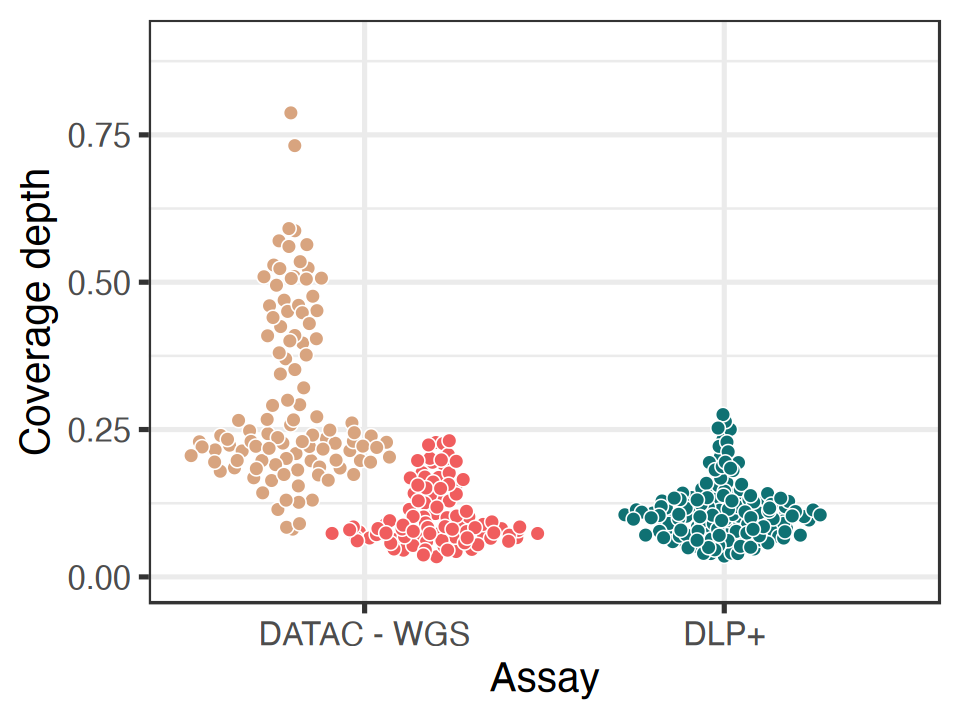

In [13]:
metrics$library_id <- factor(metrics$library_id,
                             levels = c("SW620bc_POTa","SW620_POTb","POTs_EP1"))
p <- ggplot(metrics[metrics$quality > 0.75 & metrics$is_s_phase == F & metrics$total_mapped_reads_hmmcopy >= 1000000,],
            aes(x = Mode, y = coverage_depth, fill = library_id)) +
  #geom_boxplot(alpha = 0.25)+
  geom_quasirandom(
    dodge.width = 0.8,
    shape = 21,
    color = "white",
    alpha = 1,
    size = 3.5,
    width = 0.3,         # how wide the cloud is
    varwidth = TRUE      # makes the dots follow density (violin shape)
  )+
  ylab("Coverage depth")+
  xlab("Assay")+
  guides(fill = "none", color = "none")+
  coord_cartesian(ylim = c(0,0.9))+
  scale_fill_manual(values = c("SW620bc_POTa" ="#d8a47f",
                                "SW620_POTb" ="#f05d5e",
                                "POTs_EP1" ="#0f7173"))+
  theme_bw(base_size = 24)

options(repr.plot.width=8, repr.plot.height=6)
p

Is there a significant difference in coverage depth between POTa (dATAC) and POT (DLP+)?

In [10]:
wilcox.test(metrics[metrics$quality > 0.75 & metrics$library_id == "SW620bc_POTa"& metrics$total_mapped_reads_hmmcopy >= 1000000,]$coverage_depth,
            metrics[metrics$quality > 0.75 & metrics$library_id == "POTs_EP1" & metrics$total_mapped_reads_hmmcopy >= 1000000,]$coverage_depth)


	Wilcoxon rank sum test with continuity correction

data:  metrics[metrics$quality > 0.75 & metrics$library_id == "SW620bc_POTa" & metrics$total_mapped_reads_hmmcopy >= 1e+06, ]$coverage_depth and metrics[metrics$quality > 0.75 & metrics$library_id == "POTs_EP1" & metrics$total_mapped_reads_hmmcopy >= 1e+06, ]$coverage_depth
W = 18125, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0


Is there a significant difference in coverage depth between POTa (dATAC) and POTb (dATAC)?

In [12]:
wilcox.test(metrics[metrics$quality > 0.75 & metrics$library_id == "SW620bc_POTa"& metrics$total_mapped_reads_hmmcopy >= 1000000,]$coverage_depth,
            metrics[metrics$quality > 0.75 & metrics$library_id == "SW620_POTb" & metrics$total_mapped_reads_hmmcopy >= 1000000,]$coverage_depth)


	Wilcoxon rank sum test with continuity correction

data:  metrics[metrics$quality > 0.75 & metrics$library_id == "SW620bc_POTa" & metrics$total_mapped_reads_hmmcopy >= 1e+06, ]$coverage_depth and metrics[metrics$quality > 0.75 & metrics$library_id == "SW620_POTb" & metrics$total_mapped_reads_hmmcopy >= 1e+06, ]$coverage_depth
W = 11036, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0


Is there a significant difference in coverage depth between POTb (dATAC) and POT (DLP+)?

In [11]:
wilcox.test(metrics[metrics$quality > 0.75 & metrics$library_id == "SW620_POTb"& metrics$total_mapped_reads_hmmcopy >= 1000000,]$coverage_depth,
            metrics[metrics$quality > 0.75 & metrics$library_id == "POTs_EP1"& metrics$total_mapped_reads_hmmcopy >= 1000000,]$coverage_depth)


	Wilcoxon rank sum test with continuity correction

data:  metrics[metrics$quality > 0.75 & metrics$library_id == "SW620_POTb" & metrics$total_mapped_reads_hmmcopy >= 1e+06, ]$coverage_depth and metrics[metrics$quality > 0.75 & metrics$library_id == "POTs_EP1" & metrics$total_mapped_reads_hmmcopy >= 1e+06, ]$coverage_depth
W = 7968, p-value = 0.2428
alternative hypothesis: true location shift is not equal to 0


### Coverage breadth (normalised by depth)

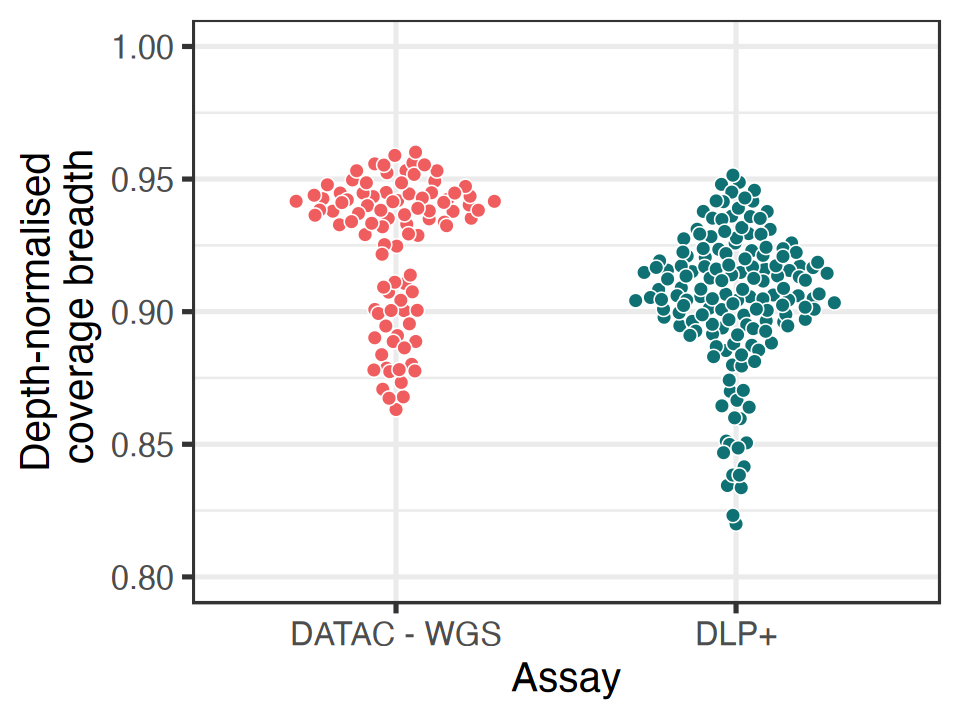

In [14]:
p <- ggplot(metrics[metrics$quality > 0.75 & metrics$is_s_phase == F & metrics$library_id != "SW620bc_POTa"  & metrics$total_mapped_reads_hmmcopy >= 1000000,],
            aes(x = Mode, y = coverage_breadth/coverage_depth, fill = Mode)) +
  #geom_boxplot(alpha = 0.5)+
  geom_quasirandom(
    dodge.width = 0.5,
    shape = 21,
    color = "white",
    alpha = 1,
    size = 3.5,
    width = 0.3,         # how wide the cloud is
    varwidth = TRUE      # makes the dots follow density (violin shape)
  )+
  ylab("Depth-normalised\n coverage breadth")+
  xlab("Assay")+
  guides(fill = "none", color = "none")+
  scale_fill_manual(values = c(`DATAC - WGS` ="#f05d5e",
                               "DLP+" ="#0f7173"))+
  coord_cartesian(ylim=c(0.8,1))+
  theme_bw(base_size = 24)
options(repr.plot.width=8, repr.plot.height=6)

p

Is there a significant difference in coverage breadth between POTb (dATAC) and POT (DLP+)?

In [15]:
wilcox.test(metrics[metrics$quality > 0.75 & metrics$is_s_phase == F & metrics$library_id == "SW620_POTb" & metrics$total_mapped_reads_hmmcopy >= 1000000,]$coverage_breadth/metrics[metrics$quality > 0.75 & metrics$is_s_phase == F& metrics$library_id == "SW620_POTb" & metrics$total_mapped_reads_hmmcopy >= 1000000,]$coverage_depth,
            metrics[metrics$quality > 0.75 & metrics$is_s_phase == F & metrics$library_id == "POTs_EP1" & metrics$total_mapped_reads_hmmcopy >= 1000000,]$coverage_breadth/metrics[metrics$quality > 0.75 & metrics$is_s_phase == F & metrics$library_id == "POTs_EP1" & metrics$total_mapped_reads_hmmcopy >= 1000000,]$coverage_depth)



	Wilcoxon rank sum test with continuity correction

data:  metrics[metrics$quality > 0.75 & metrics$is_s_phase == F & metrics$library_id == "SW620_POTb" & metrics$total_mapped_reads_hmmcopy >= 1e+06, ]$coverage_breadth/metrics[metrics$quality > 0.75 & metrics$is_s_phase == F & metrics$library_id == "SW620_POTb" & metrics$total_mapped_reads_hmmcopy >= 1e+06, ]$coverage_depth and metrics[metrics$quality > 0.75 & metrics$is_s_phase == F & metrics$library_id == "POTs_EP1" & metrics$total_mapped_reads_hmmcopy >= 1e+06, ]$coverage_breadth/metrics[metrics$quality > 0.75 & metrics$is_s_phase == F & metrics$library_id == "POTs_EP1" & metrics$total_mapped_reads_hmmcopy >= 1e+06, ]$coverage_depth
W = 10564, p-value = 4.002e-09
alternative hypothesis: true location shift is not equal to 0


### Median reads per bin

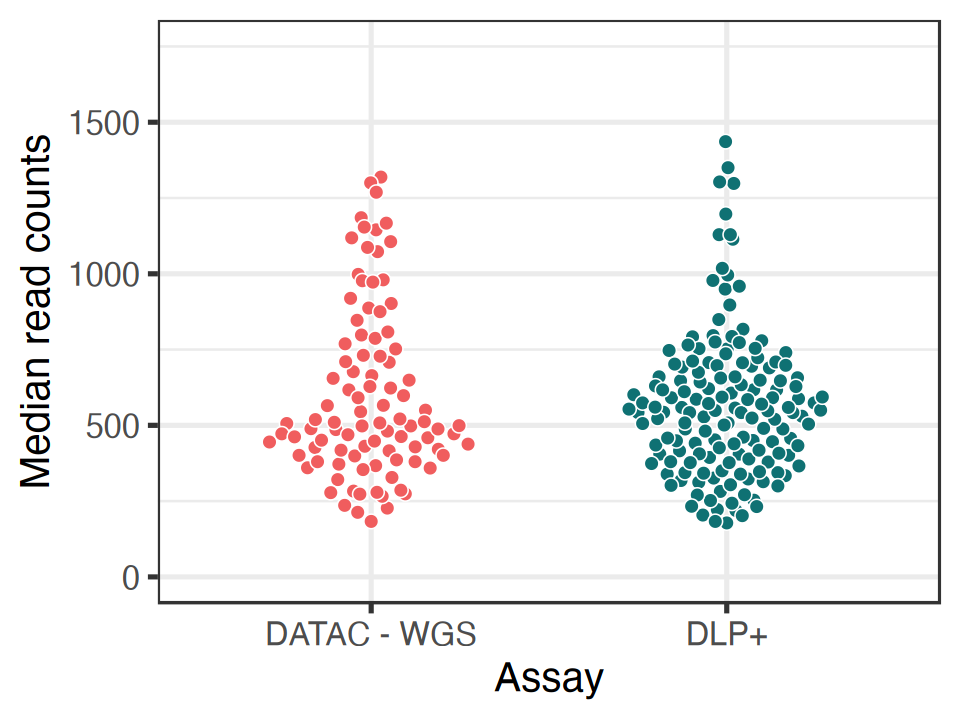

In [16]:
p <- ggplot(metrics[metrics$quality > 0.75 & metrics$is_s_phase == F & metrics$library_id != "SW620bc_POTa"  & metrics$total_mapped_reads_hmmcopy >= 1000000,],
            aes(x = Mode, y = median_hmmcopy_reads_per_bin, fill = Mode)) +
  #geom_boxplot(alpha = 0.5)+
  geom_quasirandom(
    dodge.width = 0.5,
    shape = 21,
    color = "white",
    alpha = 1,
    size = 3.5,
    width = 0.3,         # how wide the cloud is
    varwidth = TRUE      # makes the dots follow density (violin shape)
  )+
  ylab("Median read counts")+
  xlab("Assay")+
  guides(fill = "none", color = "none")+
  
  scale_fill_manual(values = c(`DATAC - WGS` ="#f05d5e",
                               "DLP+" ="#0f7173"))+
  coord_cartesian(ylim = c(0,1750))+
  theme_bw(base_size = 24)
options(repr.plot.width=8, repr.plot.height=6)

p


Is there a significant difference in median reads per bin between POTb (dATAC) and POT (DLP+)?

In [17]:
wilcox.test(metrics[metrics$quality > 0.75 & metrics$is_s_phase == F & metrics$library_id == "SW620_POTb" & metrics$total_mapped_reads_hmmcopy >= 1000000,]$median_hmmcopy_reads_per_bin,
            metrics[metrics$quality > 0.75 & metrics$is_s_phase == F & metrics$library_id == "POTs_EP1" & metrics$total_mapped_reads_hmmcopy >= 1000000,]$median_hmmcopy_reads_per_bin)


	Wilcoxon rank sum test with continuity correction

data:  metrics[metrics$quality > 0.75 & metrics$is_s_phase == F & metrics$library_id == "SW620_POTb" & metrics$total_mapped_reads_hmmcopy >= 1e+06, ]$median_hmmcopy_reads_per_bin and metrics[metrics$quality > 0.75 & metrics$is_s_phase == F & metrics$library_id == "POTs_EP1" & metrics$total_mapped_reads_hmmcopy >= 1e+06, ]$median_hmmcopy_reads_per_bin
W = 7485.5, p-value = 0.7581
alternative hypothesis: true location shift is not equal to 0


### Uniformity of coverage

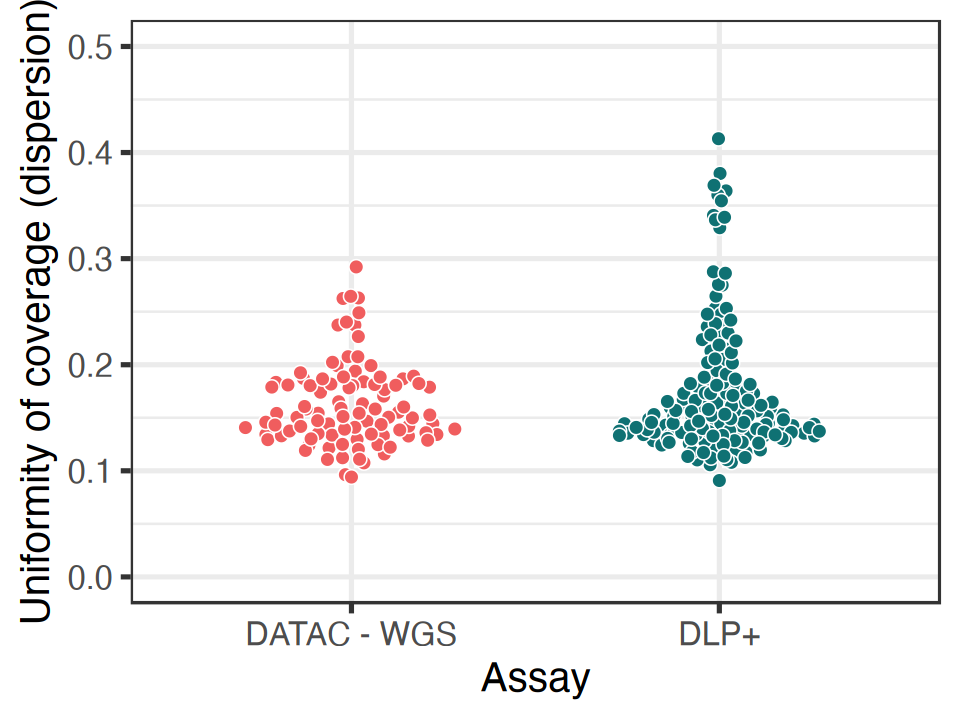

In [18]:
p <- ggplot(metrics[metrics$quality > 0.75 & metrics$is_s_phase == F & metrics$library_id != "SW620bc_POTa"  & metrics$total_mapped_reads_hmmcopy >= 1000000,], 
            aes(x = Mode, y = MBRSM_dispersion, fill = Mode)) +
#  geom_boxplot(alpha = 0.5)+
  geom_quasirandom(
    dodge.width = 0.5,
    shape = 21,
    color = "white",
    alpha = 1,
    size = 3.5,
    width = 0.3,         # how wide the cloud is
    varwidth = TRUE      # makes the dots follow density (violin shape)
  )+
  ylab("Uniformity of coverage (dispersion)")+
  xlab("Assay")+
  guides(fill = "none", color = "none")+
 
  scale_fill_manual(values = c(`DATAC - WGS` ="#f05d5e",
                               "DLP+" ="#0f7173"))+
  coord_cartesian(ylim = c(0,0.5))+
  theme_bw(base_size = 24)
options(repr.plot.width=8, repr.plot.height=6)

p

Is there a significant difference in uniformity of coverage between POTb (dATAC) and POT (DLP+)?

In [19]:
wilcox.test(metrics[metrics$quality > 0.75 & metrics$library_id == "SW620_POTb" & metrics$total_mapped_reads_hmmcopy >= 1000000,]$MBRSM_dispersion,
            metrics[metrics$quality > 0.75 & metrics$library_id == "POTs_EP1" & metrics$total_mapped_reads_hmmcopy >= 1000000,]$MBRSM_dispersion)


	Wilcoxon rank sum test with continuity correction

data:  metrics[metrics$quality > 0.75 & metrics$library_id == "SW620_POTb" & metrics$total_mapped_reads_hmmcopy >= 1e+06, ]$MBRSM_dispersion and metrics[metrics$quality > 0.75 & metrics$library_id == "POTs_EP1" & metrics$total_mapped_reads_hmmcopy >= 1e+06, ]$MBRSM_dispersion
W = 8302, p-value = 0.524
alternative hypothesis: true location shift is not equal to 0


### Proportion of duplicates

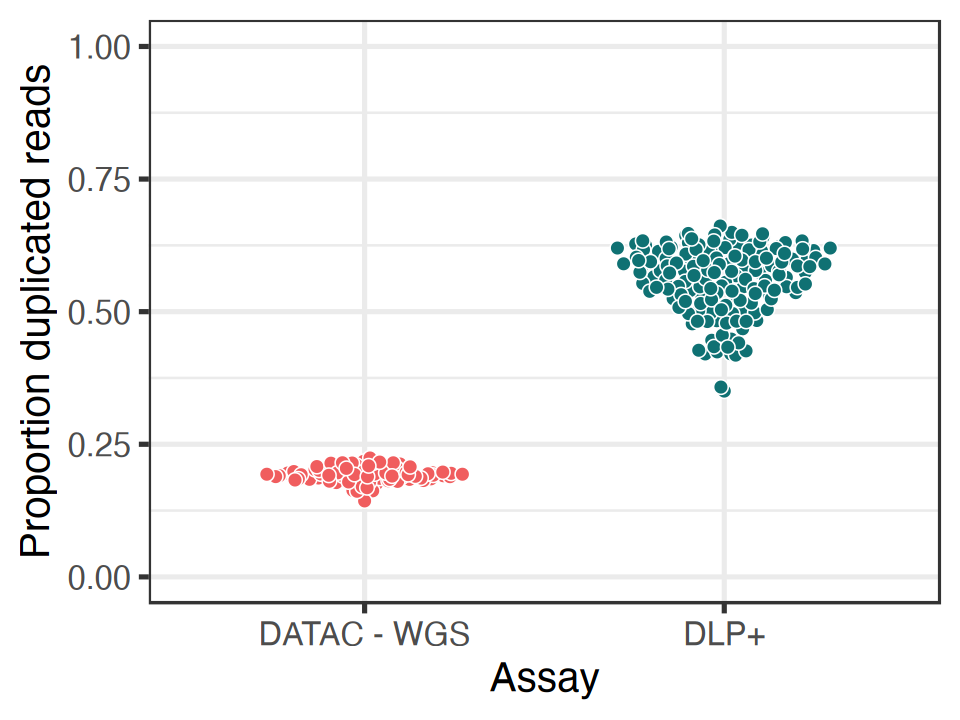

In [20]:
p <- ggplot(metrics[metrics$quality > 0.75& metrics$is_s_phase == F  & metrics$library_id != "SW620bc_POTa"  & metrics$total_mapped_reads_hmmcopy >= 1000000,],
            aes(x = Mode, y = total_duplicate_reads/total_mapped_reads,  fill = Mode)) +
  #geom_boxplot(alpha = 0.5)+
  geom_quasirandom(
    dodge.width = 0.5,
    shape = 21,
    color = "white",
    alpha = 1,
    size = 3.5,
    width = 0.3,         # how wide the cloud is
    varwidth = TRUE      # makes the dots follow density (violin shape)
  )+
  ylab("Proportion duplicated reads")+
  xlab("Assay")+
  guides(fill = "none", color = "none")+
 
  scale_fill_manual(values = c(`DATAC - WGS` ="#f05d5e",
                               "DLP+" ="#0f7173"))+
  coord_cartesian(ylim = c(0,1))+
  theme_bw(base_size = 24)
options(repr.plot.width=8, repr.plot.height=6)

p

Is there a significant difference in the proportion of duplicates between POTb (dATAC) and POT (DLP+)?

In [21]:
wilcox.test(metrics[metrics$quality > 0.75 & metrics$library_id == "SW620_POTb" & metrics$total_mapped_reads_hmmcopy >= 1000000,]$total_duplicate_reads/metrics[metrics$quality > 0.75 & metrics$library_id == "SW620_POTb" & metrics$total_mapped_reads_hmmcopy >= 1000000,]$total_mapped_reads,
            metrics[metrics$quality > 0.75 & metrics$library_id == "POTs_EP1" & metrics$total_mapped_reads_hmmcopy >= 1000000,]$total_duplicate_reads/metrics[metrics$quality > 0.75 & metrics$library_id == "POTs_EP1" & metrics$total_mapped_reads_hmmcopy >= 1000000,]$total_mapped_reads)


	Wilcoxon rank sum test with continuity correction

data:  metrics[metrics$quality > 0.75 & metrics$library_id == "SW620_POTb" & metrics$total_mapped_reads_hmmcopy >= 1e+06, ]$total_duplicate_reads/metrics[metrics$quality > 0.75 & metrics$library_id == "SW620_POTb" & metrics$total_mapped_reads_hmmcopy >= 1e+06, ]$total_mapped_reads and metrics[metrics$quality > 0.75 & metrics$library_id == "POTs_EP1" & metrics$total_mapped_reads_hmmcopy >= 1e+06, ]$total_duplicate_reads/metrics[metrics$quality > 0.75 & metrics$library_id == "POTs_EP1" & metrics$total_mapped_reads_hmmcopy >= 1e+06, ]$total_mapped_reads
W = 0, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0


### Median absolute deviation (MAD) in diploid regions

Warning message:
“Removed 3 rows containing missing values (`position_quasirandom()`).”


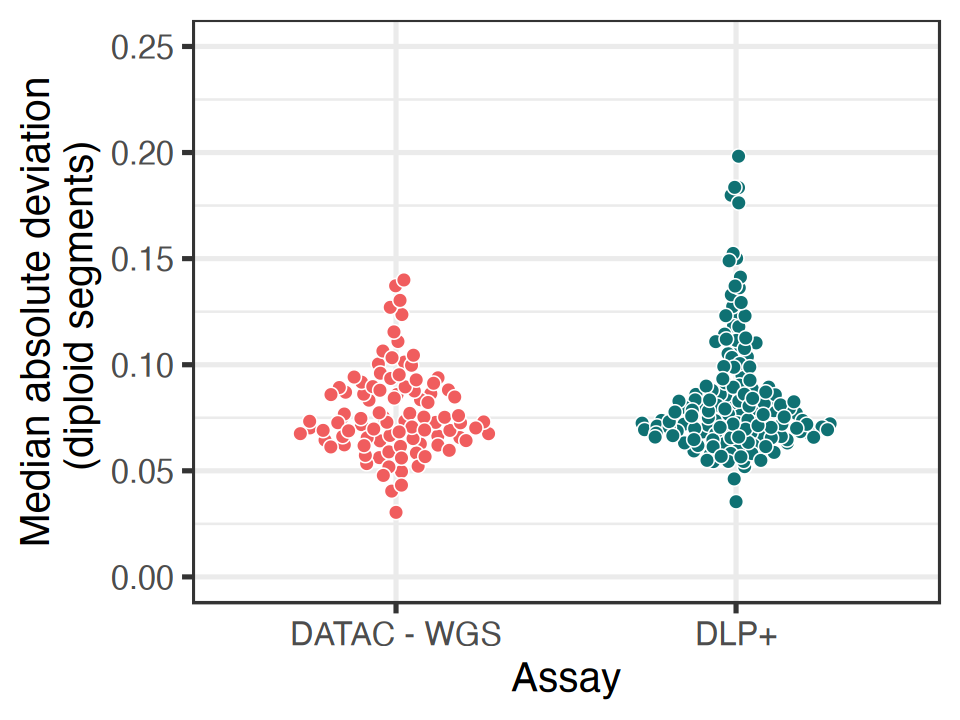

In [22]:
p <- ggplot(metrics[metrics$quality > 0.75 & metrics$is_s_phase == F & metrics$library_id != "SW620bc_POTa"  & metrics$total_mapped_reads_hmmcopy >= 1000000,],
            aes(x = Mode, y = mad_neutral_state, fill = Mode)) +
  #geom_boxplot(alpha = 0.5)+
  geom_quasirandom(
    dodge.width = 0.5,
    shape = 21,
    color = "white",
    alpha = 1,
    size = 3.5,
    width = 0.3,         # how wide the cloud is
    varwidth = TRUE      # makes the dots follow density (violin shape)
  )+
  ylab("Median absolute deviation\n (diploid segments)")+
  xlab("Assay")+
  guides(fill = "none", color = "none")+

  scale_fill_manual(values = c(`DATAC - WGS` ="#f05d5e",
                               "DLP+" ="#0f7173"))+
  coord_cartesian(ylim = c(0,0.25))+
  theme_bw(base_size = 24)
options(repr.plot.width=8, repr.plot.height=6)

p

Is there a significant difference in MAD in diploid region between POTb (dATAC) and POT (DLP+)?

In [23]:
wilcox.test(metrics[metrics$quality > 0.75 & metrics$library_id == "SW620_POTb"& metrics$total_mapped_reads_hmmcopy >= 1000000,]$mad_neutral_state,
            metrics[metrics$quality > 0.75 & metrics$library_id == "POTs_EP1"& metrics$total_mapped_reads_hmmcopy >= 1000000,]$mad_neutral_state)


	Wilcoxon rank sum test with continuity correction

data:  metrics[metrics$quality > 0.75 & metrics$library_id == "SW620_POTb" & metrics$total_mapped_reads_hmmcopy >= 1e+06, ]$mad_neutral_state and metrics[metrics$quality > 0.75 & metrics$library_id == "POTs_EP1" & metrics$total_mapped_reads_hmmcopy >= 1e+06, ]$mad_neutral_state
W = 7943, p-value = 0.3694
alternative hypothesis: true location shift is not equal to 0


### Median absolute deviation (MAD) across all copy number segments

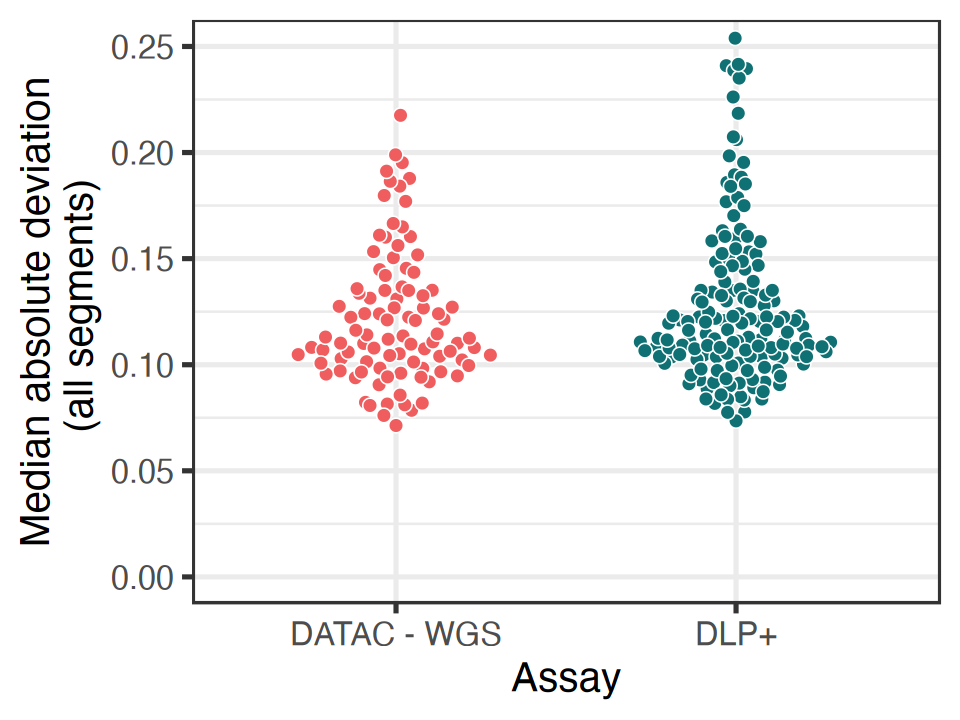

In [24]:
p <- ggplot(metrics[metrics$quality > 0.75 & metrics$is_s_phase == F & metrics$library_id != "SW620bc_POTa"  & metrics$total_mapped_reads_hmmcopy >= 1000000,],
            aes(x = Mode, y = mad_hmmcopy, fill = Mode)) +
  #geom_boxplot(alpha = 0.5)+
  geom_quasirandom(
    dodge.width = 0.5,
    shape = 21,
    color = "white",
    alpha = 1,
    size = 3.5,
    width = 0.3,         # how wide the cloud is
    varwidth = TRUE      # makes the dots follow density (violin shape)
  )+
  ylab("Median absolute deviation\n (all segments)")+
  xlab("Assay")+
  guides(fill = "none", color = "none")+
  scale_fill_manual(values = c(`DATAC - WGS` ="#f05d5e",
                               "DLP+" ="#0f7173"))+
  coord_cartesian(ylim = c(0,0.25))+
  theme_bw(base_size = 24)
options(repr.plot.width=8, repr.plot.height=6)

p

Is there a significant difference in genome-wide MAD between POTb (dATAC) and POT (DLP+)?

In [25]:
wilcox.test(metrics[metrics$quality > 0.75 & metrics$library_id == "SW620_POTb"& metrics$total_mapped_reads_hmmcopy >= 1000000,]$mad_hmmcopy,
            metrics[metrics$quality > 0.75 & metrics$library_id == "POTs_EP1"& metrics$total_mapped_reads_hmmcopy >= 1000000,]$mad_hmmcopy)


	Wilcoxon rank sum test with continuity correction

data:  metrics[metrics$quality > 0.75 & metrics$library_id == "SW620_POTb" & metrics$total_mapped_reads_hmmcopy >= 1e+06, ]$mad_hmmcopy and metrics[metrics$quality > 0.75 & metrics$library_id == "POTs_EP1" & metrics$total_mapped_reads_hmmcopy >= 1e+06, ]$mad_hmmcopy
W = 8246, p-value = 0.4677
alternative hypothesis: true location shift is not equal to 0


### WGS library complexity

Rows: 1830 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): Sample
dbl (2): Total_mapped_reads, Proportion_duplicates

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


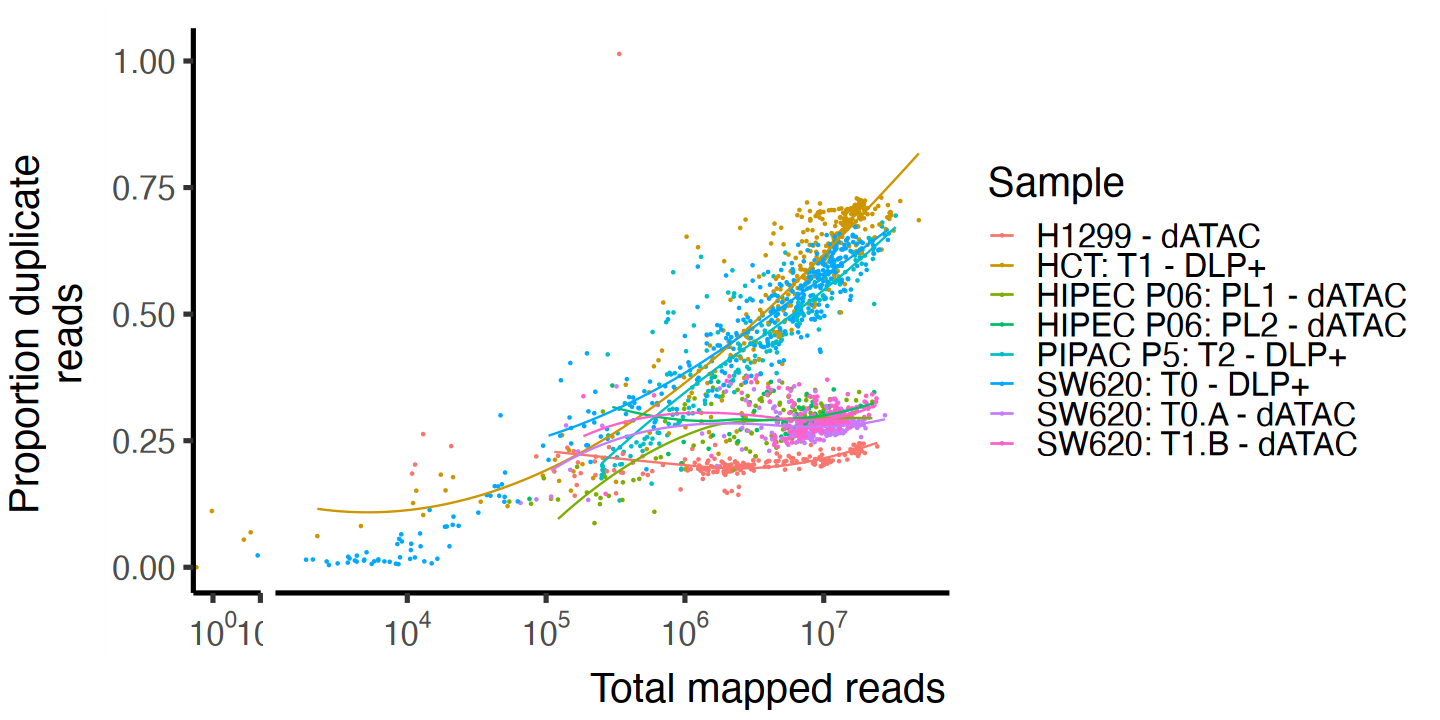

In [8]:
lib_sizes <- data.frame(read_csv("../Data/CNA_Data/Raw/QC/WGS_LibraryComplexity.csv"))

p <- ggplot()+
  geom_point(data = lib_sizes,
             aes(x = log10(Total_mapped_reads), y = Proportion_duplicates, color = Sample),
             size = 0.25) +
  geom_smooth(data = lib_sizes[lib_sizes$Sample %in% c("HCT: T1 - DLP+") & lib_sizes$Total_mapped_reads >= 10^3,],
              aes(x = log10(Total_mapped_reads), y = Proportion_duplicates, color = Sample, fill = Sample),
              se = F,
              method = "loess",
              linewidth = 0.5,
              span = 1) +
geom_smooth(data = lib_sizes[! lib_sizes$Sample %in% c("HCT: T1 - DLP+") & lib_sizes$Total_mapped_reads >= 10^5,],
            aes(x = log10(Total_mapped_reads), y = Proportion_duplicates, color = Sample, fill = Sample),
            se = F,
            method = "loess",
            span = 1,
            linewidth = 0.5) +
  scale_x_continuous( breaks = c(1,3, 4, 5, 6, 7,8),
                      labels = c(expression(10^0),expression(10^3), expression(10^4), expression(10^5),
                                 expression(10^6), expression(10^7), expression(10^8)))+
  ggbreak::scale_x_break(c(log10(770), log10(1865)), 10) +
  xlab("Total mapped reads")+
  ylab("Proportion duplicate\nreads")+
  theme_classic(base_size = 24) +
  theme(  axis.line.x.top  = element_blank(),
          axis.ticks.x.top = element_blank(),
          axis.text.x.top  = element_blank())

options(repr.plot.width=12, repr.plot.height=6)
print(p)

## Subclone analysis

In [27]:
# Import and format CNA data 
cnv_data_datac_a <- data.frame(fread("../Data/CNA_Data/Raw/QC/SW620_POTa_reads.csv.gz")) 
cnv_data_datac_b <- data.frame(fread("../Data/CNA_Data/Raw/QC/SW620_POTb_reads.csv.gz"))
cnv_data_atac <- data.frame(fread("../Data/CNA_Data/Raw/QC/POTs_EP1_reads.csv.gz"))

cnv_data <- rbind(cnv_data_datac_a,
                  cnv_data_datac_b,
                  cnv_data_atac)

# Format the CNV data 
cnv_data_fil <- cnv_data %>% dplyr::mutate(Location = sprintf("%s:%s-%s",chr,start,end)) %>%
  dplyr::arrange(as.numeric(chr)) %>% 
  dplyr::filter(cell_id %in% metrics[metrics$quality > 0.75 & metrics$is_s_phase == F & metrics$total_mapped_reads_hmmcopy >= 1000000,]$cell_id) %>% 
  dplyr::filter(map > 0.99) %>%
  dplyr::mutate_at("cell_id",str_replace,"-SW620bc_POTa|-SW620_POTb|-POTs_EP1","") %>%
  dplyr::select(cell_id,chr,start,end,state)

colnames(cnv_data_fil) <- c("cell_id","chrom","start","end","state")
length(unique(cnv_data_fil$cell_id))

Warning message:
“There was 1 warning in `dplyr::arrange()`.
ℹ In argument: `..1 = as.numeric(chr)`.
Caused by warning:
! NAs introduced by coercion”


[1] 357

### Visualise subclones on the CNA profile heatmap

Warning message:
“Setting row names on a tibble is deprecated.”
`use_raster` is automatically set to TRUE for a matrix with more than
2000 columns You can control `use_raster` argument by explicitly
setting TRUE/FALSE to it.

Set `ht_opt$message = FALSE` to turn off this message.

`use_raster` is automatically set to TRUE for a matrix with more than
2000 columns You can control `use_raster` argument by explicitly
setting TRUE/FALSE to it.

Set `ht_opt$message = FALSE` to turn off this message.



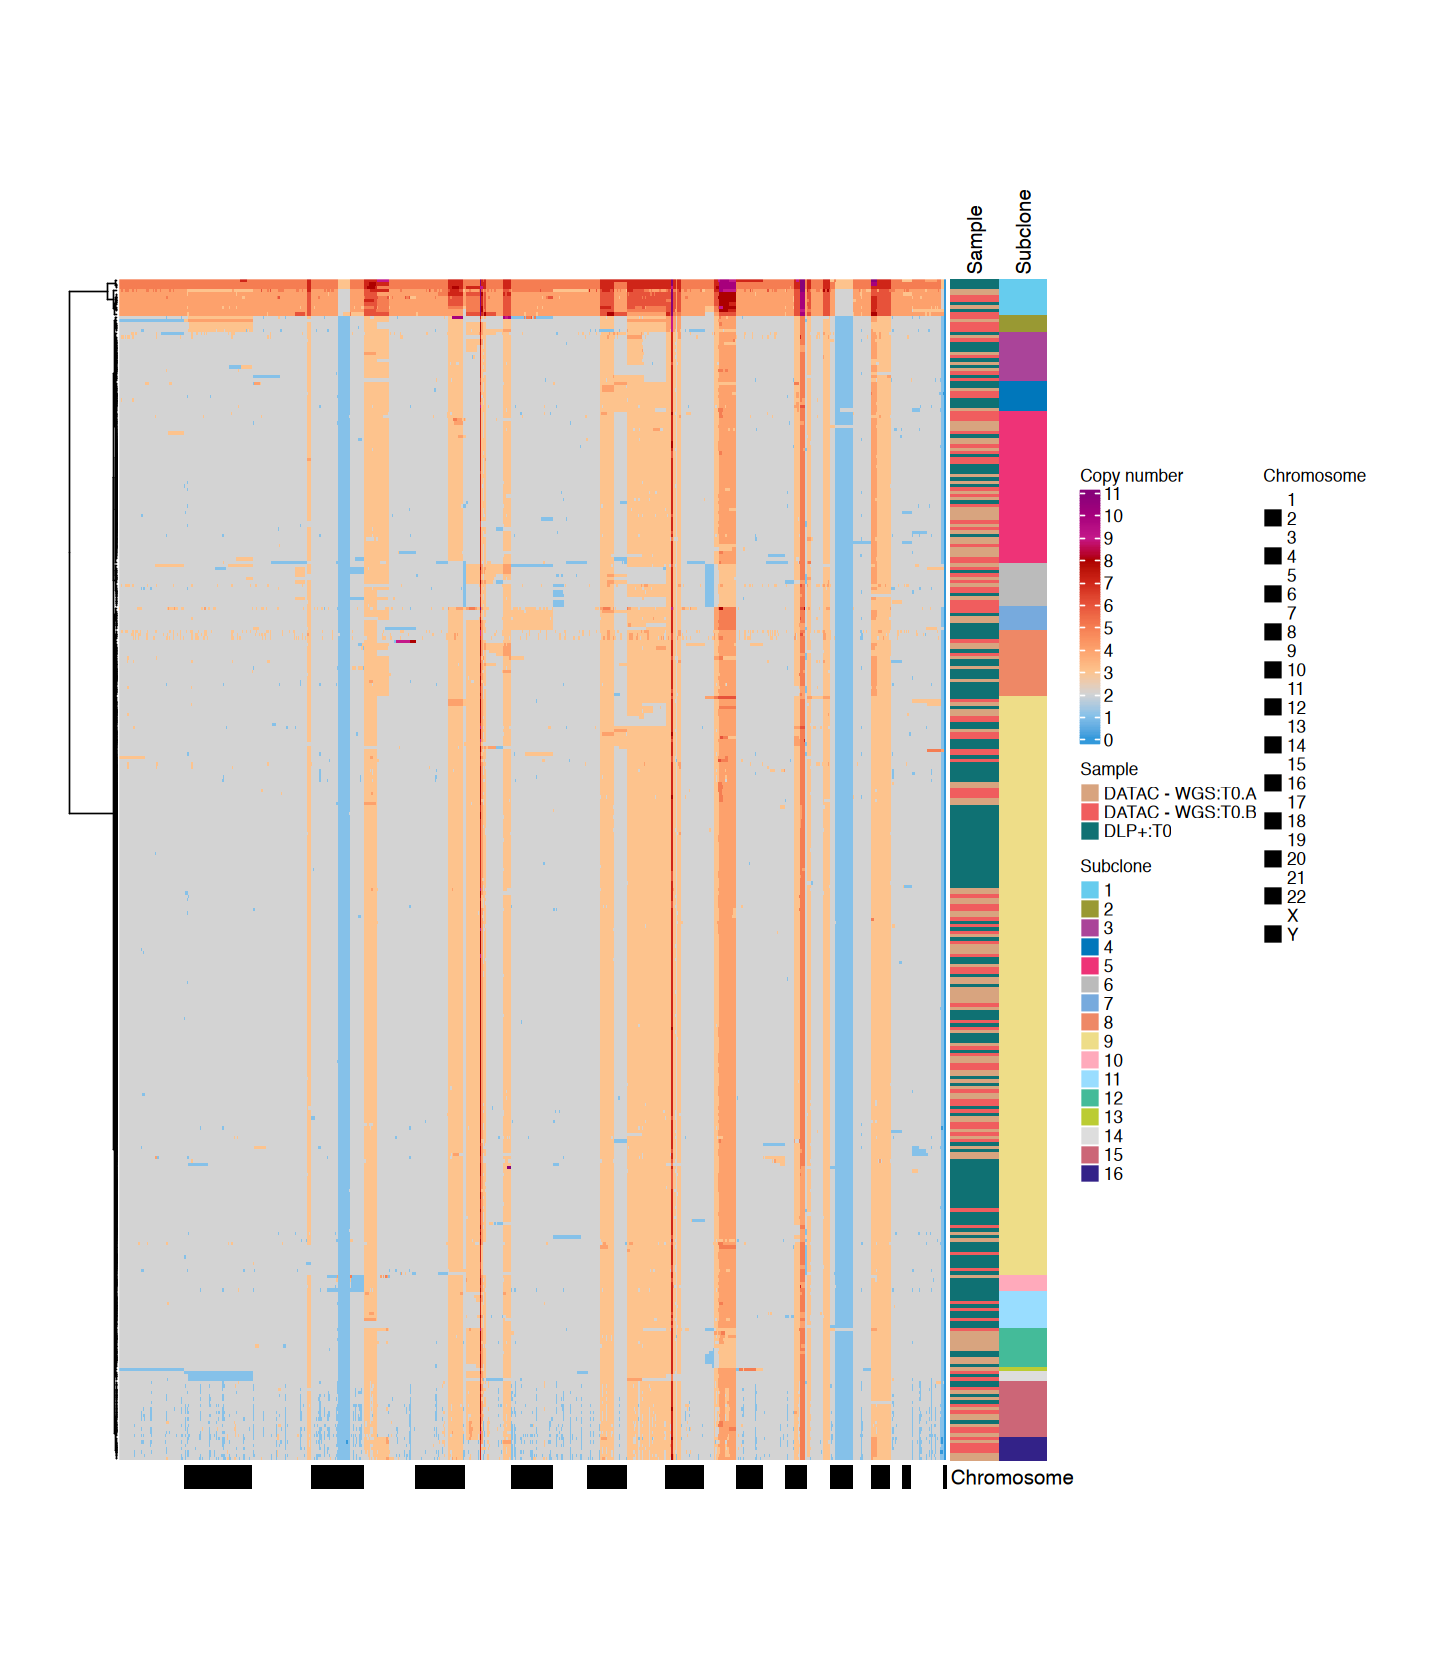

In [31]:
#Plot the CNA heatmap to define subclones

# Add genomic position information
cna_data <- cnv_data_fil %>% dplyr::mutate(Location = sprintf("%s:%s-%s",chrom,start,end))

# Format cna data for heatmap plot
cna_df <- cna_data[,c("cell_id","state","Location")] %>% tidyr::pivot_wider(names_from = Location,
                                                                            values_from = `state`)
rownames(cna_df) <- cna_df$cell_id

cna_mat <- as.matrix(cna_df[,-1])
rownames(cna_mat) <- rownames(cna_df)


sample <- unlist(str_split(rownames(cna_df),"_DATAC|_DLP"))[seq(1,2*nrow(cna_df),2)]
sample[grep("POTm",sample)] <- "DATAC - WGS:T0.A"
sample[grep("POTp",sample)] <- "DATAC - WGS:T0.B"
sample[grep("POTs",sample)] <- "DLP+:T0"

sample <- factor(sample,levels = c("DATAC - WGS:T0.A","DATAC - WGS:T0.B","DLP+:T0"))

row_annotation_r <- data.frame(sample)
colnames(row_annotation_r) <- c("Sample")
rownames(row_annotation_r) <- rownames(cna_df)


row_annotation_r_h <- ComplexHeatmap::rowAnnotation(df = row_annotation_r,
                                                    col = list( `Sample` =  c("DATAC - WGS:T0.A" = "#d8a47f",
                                                                              "DATAC - WGS:T0.B" = "#f05d5e",
                                                                              "DLP+:T0" =  "#0f7173")),
                                                    simple_anno_size = unit(1, "cm"),
                                                    annotation_name_side = "top"
)


# Column annotation to separate chromosomes, listed in order 1,2,3,...,22,X
column_annotation <- data.frame(unlist(strsplit(colnames(cna_mat), split=':', fixed=TRUE))[seq(1,length(colnames(cna_mat))*2,by=2)])
colnames(column_annotation) <- "Chromosome"
rownames(column_annotation) <- colnames(cna_mat)
column_annotation$Chromosome <- factor(column_annotation$Chromosome, levels = c(sprintf("%s",c(1:22)),"X","Y"))

column_annotation_h <- ComplexHeatmap::HeatmapAnnotation(df = column_annotation,
                                                         col = list(Chromosome = c("1"="white", "2"="black", "3"="white", "4"="black",
                                                                                   "5"="white", "6"="black","7"="white", "8"="black",
                                                                                   "9"="white", "10"="black","11"="white", "12"="black",
                                                                                   "13"="white", "14"="black","15"="white", "16"="black",
                                                                                   "17"="white", "18"="black","19"="white", "20"="black",
                                                                                   "21"="white", "22"="black","X"="white","Y"="black") ),
                                                         simple_anno_size = unit(0.5, "cm")
)

# Define heatmap colours

myColor <- c("#3399db","#85c1e9","#d3d3d3","#fdc38d","#fda16c","#f57d52",
             "#e7523a","#cf2518","#ad0000","#c4188a","#a7007c","#87027a")
myBreaks <- seq(0,11,1)

colours <- circlize::colorRamp2(myBreaks,myColor) 


# Plot heatmap
h <- ComplexHeatmap::Heatmap(as.matrix(cna_mat), 
                             col = colours,
                             bottom_annotation = column_annotation_h,
                             right_annotation = row_annotation_r_h,
                             cluster_columns = F,
                             cluster_rows = T,
                             clustering_distance_rows = "manhattan",
                             clustering_method_rows = "ward.D2",
                             show_column_names = FALSE,
                             show_row_names =F,
                             heatmap_legend_param = list(title = "Copy number",
                                                         at = myBreaks),
                             raster_quality = 10,
                             width = unit(17.5,"cm"),
                             height = unit(25,"cm"))

# get row order of the clustered heatmap
ht <- draw(h)          
cell_order <- rownames(cna_mat)[row_order(ht)] 

# Now add subclones

df <- data.frame("Cell" = cell_order, "Subclone" = c(rep(1,11),
  rep(2,5),
  rep(3,15),
  rep(4,9),
  rep(5,46),
  rep(6,13),
  rep(7,7),
  rep(8,20),
  rep(9,175),
  rep(10,5),
  rep(11,11),
  rep(12,12),
  rep(13,1),
  rep(14,3),
  rep(15,17),
  rep(16,7)))
rownames(df) <- df$Cell

df <- df[rownames(cna_df),]

row_annotation_r <- data.frame(sample, as.character(df$Subclone))
colnames(row_annotation_r) <- c("Sample","Subclone")
rownames(row_annotation_r) <- rownames(cna_df)

row_annotation_r$Subclone <- factor(row_annotation_r$Subclone, levels = sprintf("%s",1:16))

library("khroma")
pal32 <- c(colour("bright")(7), colour("vibrant")(7),colour("light")(9),colour("muted")(9))
my_cols <- pal32[-c(1,2,3,4,6,7,8,10,12,13,22,26,28,30)]
my_cols <- c(my_cols[c(1, 17:18,2:16)])

row_annotation_r_h <- ComplexHeatmap::rowAnnotation(df = row_annotation_r,
                                                    col = list( `Sample` =  c("DATAC - WGS:T0.A" = "#d8a47f",
                                                                              "DATAC - WGS:T0.B" = "#f05d5e",
                                                                              "DLP+:T0" =  "#0f7173"),
                                                                `Subclone` = setNames(my_cols, sprintf("%s",1:18))),
                                                    simple_anno_size = unit(1, "cm"),
                                                    annotation_name_side = "top"
)

options(repr.plot.width=12, repr.plot.height=14)

# Plot heatmap
h <- ComplexHeatmap::Heatmap(as.matrix(cna_mat), 
                             col = colours,
                             bottom_annotation = column_annotation_h,
                             right_annotation = row_annotation_r_h,
                             cluster_columns = F,
                             cluster_rows = T,
                             clustering_distance_rows = "manhattan",
                             clustering_method_rows = "ward.D2",
                             show_column_names = FALSE,
                             show_row_names =F,
                             heatmap_legend_param = list(title = "Copy number",
                                                         at = myBreaks),
                             raster_quality = 10,
                             width = unit(17.5,"cm"),
                             height = unit(25,"cm"))


# Draw the heatmap
draw(h, heatmap_legend_side = "right", annotation_legend_side = "right")

### Compare the CNAs detected by DLP+ and dATAC - WGS

#### 1. Minimum segmentation across joint DLP+ and dATAC - WGS data

In [ ]:
# 1. Min seg per cell
chroms <- c(sprintf("%s",1:22),"X","Y")
bin_size <- 500000
col_names <- c("cell_id","chrom","start","end","state")
ids <- unique(cnv_data_fil$cell_id)

# Per cell segmentation dataframe
df_og <- min_cell_segmentation_per_cell(cnv_data_fil,chroms,ids, bin_size, col_names)

# Per cell segmentation GRanges
list <- c()
for (id in ids){
  temp <- df_og %>% filter(cell_id == id)
  seq_counts <- temp %>% dplyr::count(chrom)
  seq_counts <- seq_counts[str_order(seq_counts$chrom,numeric = TRUE),]
  gr <- GRanges(seqnames = Rle(sprintf("chr%s",seq_counts$chrom),seq_counts$n),
                ranges = IRanges(start = as.numeric(temp$start),end = as.numeric(temp$end)))
  mcols(gr)$state <- temp$state 
  mcols(gr)$cell_id <- rep(id,nrow(temp))
  list <- c(list,gr)
}

list <- GRangesList(list)
orig_segs <- list

# 2. consistent segmentation across all cells
chroms <- c(sprintf("%s",1:22),"X","Y")
bin_size <- 500000
col_names <- c("cell_id","chrom","start","end","state")
df <- min_consistent_segmentation(cnv_data_fil,bin_size,chroms,col_names)


# segments after joint segmentation
chroms <- c(sprintf("%s",1:22),"X","Y")
ids <- unique(cnv_data_fil$cell_id)
list <- c()
for (id in ids){
  temp <- df %>% filter(cell_id == id)
  seq_counts <- temp %>% dplyr::count(chrom)
  seq_counts <- seq_counts[str_order(seq_counts$chrom,numeric = TRUE),]
  gr <- GRanges(seqnames = Rle(seq_counts$chrom,seq_counts$n),
                ranges = IRanges(start = as.numeric(temp$start),end = as.numeric(temp$end)))
  mcols(gr)$state <- temp$state 
  mcols(gr)$cell_id <- rep(id,nrow(temp))
  list <- c(list,gr)
}

list <- GRangesList(list)
segs_gr <- list

# Create the adjusted consistent segmentation
# start the code
min_w = 1e6
max_g <-1e6
segs <- merge_small_segments(segs_gr, orig_segs, min_width = min_w, max_gap = max_g)
segs_fin <- merge_gaps(segs,fill_gap_width = 1e6)


a <- do.call(cbind.data.frame, segs_fin)
segs_final <- data.frame(Col1 = character(),
                         Col2 = integer(), 
                         Col2 = integer(), 
                         Col2 = integer(),
                         Col1 = character(), 
                         stringsAsFactors = FALSE) 

for (i in 1:length(ids)){
  segs_final <- rbind(segs_final,a[c((1+(i-1)*7):(3+(i-1)*7),(6+(i-1)*7):(i*7))])
}

segs_final <- segs_final[c("cell_id","seqnames","start","end","state")]
colnames(segs_final) <- c("cell_id","chrom","start","end","state")

#write_tsv(segs_final,"../Data/CNA_Data/Processed/QC_POT_CNA_Profiles_Segmented.tsv")


#### 2. Refinement of the segmentation to account for breakpoint uncertainty and counts of each CNA in the dATAC- and DLP+-processed cells

In [9]:
chroms    <- c(sprintf("chr%s", 1:22), "chrX", "chrY")
col_names <- c("cell_id", "chrom", "start", "end", "state")
tolerance <- 2e6  # 2 Mb

# 1) Read + per-cell mean + choose diploid cells (mean copy number state <= 3)
cna <- read_tsv("../Data/CNA_Data/Processed/QC_POT_CNA_Profiles_Segmented.tsv") %>%
  group_by(cell_id) %>%
  mutate(mean_state = mean(state, na.rm = TRUE)) %>%
  ungroup()

cell_ids_diploid <- cna %>%
  filter(mean_state <= 3) %>%
  distinct(cell_id) %>%
  pull(cell_id)


# 2) Segment (your function)
segs <- min_cell_segmentation_per_cell_segmented_data(
  cna %>% filter(cell_id %in% cell_ids_diploid),
  chroms   = chroms,
  ids      = cell_ids_diploid,
  column_names = col_names
)

# 3) Add sample label safely
segs <- segs %>%
  mutate(
    sample = case_when(
      str_detect(cell_id, "POTm|POTp") ~ "DATAC - WGS",
      str_detect(cell_id, "POTs")      ~ "DLP+",
      TRUE                             ~ NA_character_
    ),
    start = as.numeric(start),
    end   = as.numeric(end),
    length = end - start
  )

# 4) Count cells per segment per sample; wide; filter long segments + prevalence
seg_counts_wide <- segs %>%
  group_by(chrom, start, end, state, sample) %>%
  summarise(n_cells = n_distinct(cell_id), .groups = "drop") %>%
  filter((end - start) >= 5e6) %>%
  pivot_wider(
    names_from  = sample,
    values_from = n_cells,
    names_prefix = "cells_"
  ) %>%
  # NA -> 0 for downstream filters
  replace_na(list(`cells_DATAC - WGS` = 0, `cells_DLP+` = 0)) %>%
  # prevalence filter (>=1% of each cohort, using your hard-coded denominators)
  filter(
    `cells_DATAC - WGS` >= ceiling(199 * 0.01) |
      `cells_DLP+`      >= ceiling(151 * 0.01)
  ) %>%
  # autosomes: drop neutral state=2; keep chrX/chrY regardless
  filter((! chrom %in% c("chrX", "chrY") & state != 2) | (chrom %in% c("chrX", "chrY")))

# 5) Convert to a simple df + cluster “nearly matching” breakpoints within tolerance
cluster_breakpoints <- function(d, tol = 2e6) {
  d <- d %>%
    arrange(chrom, state, start, end) %>%
    mutate(
      cluster = {
        cl <- integer(n())
        cid <- 1L
        cl[1] <- cid
        for (i in 2:n()) {
          same_chrom <- chrom[i] == chrom[i - 1]
          same_state <- state[i] == state[i - 1]

          rule1 <- (start[i] == start[i - 1]) && (abs(end[i] - end[i - 1]) <= tol)
          rule2 <- (end[i]   == end[i - 1])   && (abs(start[i] - start[i - 1]) <= tol)

          if (same_chrom && same_state && (rule1 || rule2)) {
            cl[i] <- cid
          } else {
            cid <- cid + 1L
            cl[i] <- cid
          }
        }
        cl
      }
    )
  d
}

bp_df <- seg_counts_wide %>%
  transmute(
    chrom,
    start,
    end,
    state,
    count_A = `cells_DATAC - WGS`,
    count_B = `cells_DLP+`
  ) %>%
  cluster_breakpoints(tol = tolerance)

merged_df <- bp_df %>%
  group_by(cluster, chrom, state) %>%
  summarise(
    start   = min(start),
    end     = max(end),
    count_A = sum(count_A),
    count_B = sum(count_B),
    .groups = "drop"
  )

write_csv(merged_df, "../Data/CNA_Data/Processed/QC_ConsistentSegments_CountsPerAssay.csv")


Rows: 560133 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): cell_id, chrom
dbl (3): start, end, state

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Note: further manual curation of merged_df was required to avoid counting what was likely to be the same event as two separate events in the DLP+ vs dATAC counts. The manually curated dataframe can be found under "../Data/CNA_Data/Processed/QC_ConsistentSegments_CountsPerAssay_Edited.csv"

#### 3. Plot the results

Rows: 255 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): chrom
dbl (6): cluster, state, start, end, count_A, count_B

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
`geom_smooth()` using formula = 'y ~ x'


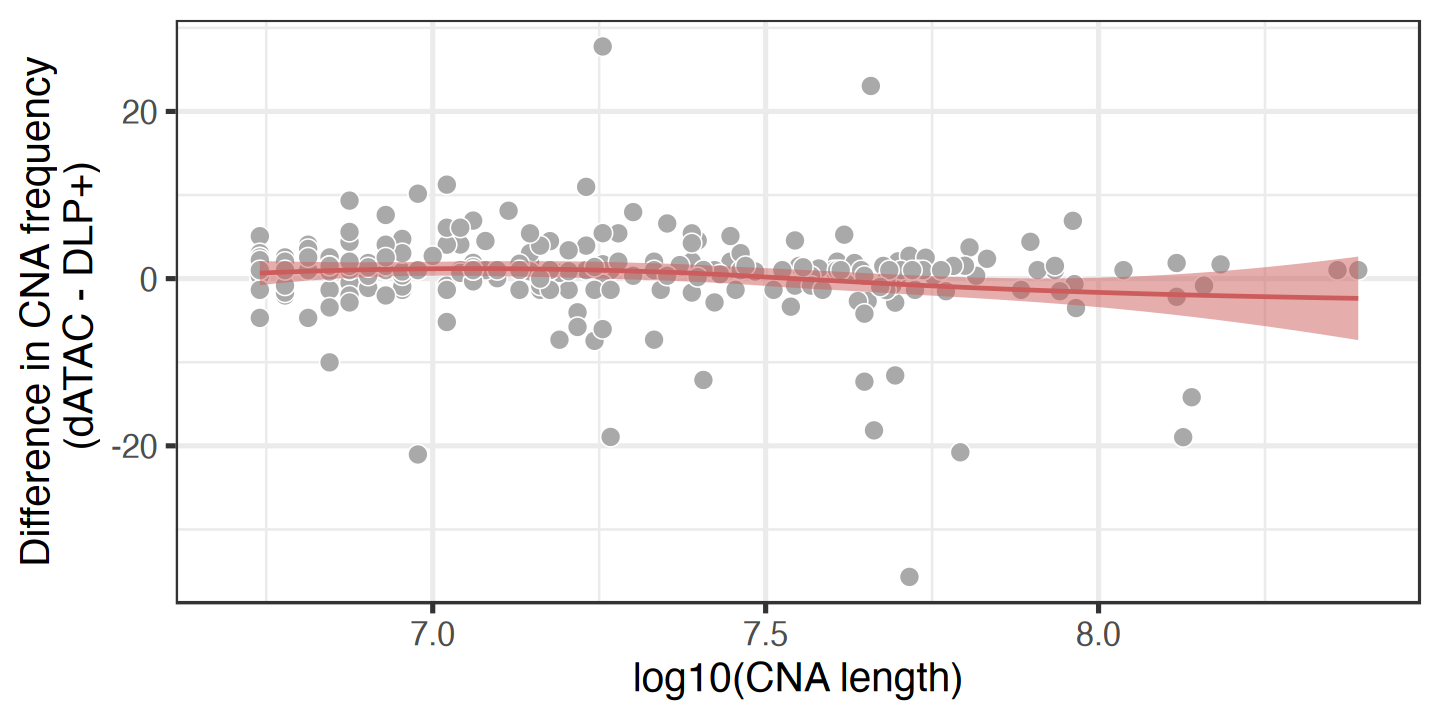

In [26]:
merged_df <- read_csv("../Data/CNA_Data/Processed/QC_ConsistentSegments_CountsPerAssay_Edited.csv")

centromeres <- data.frame(read.table("../Data/Other/Centromeres.txt",
                                                    header = T))
lengths <- data.frame(read.table("../Data/Other/ChromLengths.txt",
                                     header = T))

merged_df <- merged_df %>% mutate(P_A = count_A/length(grep("POTm|POTp",cell_ids_diploid))) %>%
  mutate(P_B = count_B/length(grep("POTs",cell_ids_diploid))) %>% left_join(centromeres, by = "chrom") %>%
  left_join(lengths, by = "chrom") %>% 
  mutate(length = end-start)

merged_df <- merged_df %>% 
  mutate(SizeCol = case_when(length >= 0.8*chrom_length ~ "whole",
                             end <= chromStart & length >= 0.8*chromEnd ~ "arm",
                             start <= chromStart & end < chromEnd + 10000000 & length >= 1*chromEnd ~ "arm",
                             start > chromStart & length >= 0.8*(chrom_length - chromEnd) ~ "arm",
                             start > chromStart - 10000000 & end > chromEnd & length >= 1*(chrom_length - chromEnd) ~ "arm",
                             (end <= chromStart & length < 0.8*chromStart  & length >= 0.4*chromStart) |
                               (start > chromEnd & length < 0.8*(chrom_length - chromEnd) & length >= 0.4*(chrom_length - chromEnd)) ~ "focal (large)",
                             (end <= chromStart & length < 0.4*chromStart) |
                               (start > chromEnd &  length < 0.4*(chrom_length - chromEnd)) ~ "focal (small)"
                             ))
merged_df[which(is.na(merged_df$SizeCol)),]$SizeCol <- c("arm",
                                                         "focal (large)",
                                                         "focal (small)",
                                                         "focal (small)",
                                                         "focal (small)",
                                                         "arm",
                                                         "arm",
                                                         "arm",
                                                         "arm",
                                                         "focal (large)",
                                                         "focal (small)",
                                                         "focal (small)",
                                                         "focal (small)",
                                                         "focal (small)",
                                                         "focal (small)",
                                                         "arm",
                                                         "arm",
                                                         "focal (large)",
                                                         "focal (large)",
                                                         "focal (small)")
  
p <- ggplot(data = merged_df, aes(x = log10(length), y = 100*(P_A-P_B)))+
  geom_point(shape = 21, alpha = 1, color = "white", fill = "darkgrey", size = 5) +
  geom_smooth( aes(x = log10(length), y = 100*(P_A-P_B)),
               alpha = 0.5, color = "indianred", fill = "indianred",method = "loess",
              span = 1)+
  xlab("log10(CNA length)")+
  ylab("Difference in CNA frequency\n (dATAC - DLP+)")+
  coord_cartesian(xlim = c(log10(5000000), log10(250000000)))+
  theme_bw(base_size = 24)
options(repr.plot.width=12, repr.plot.height=6)
p


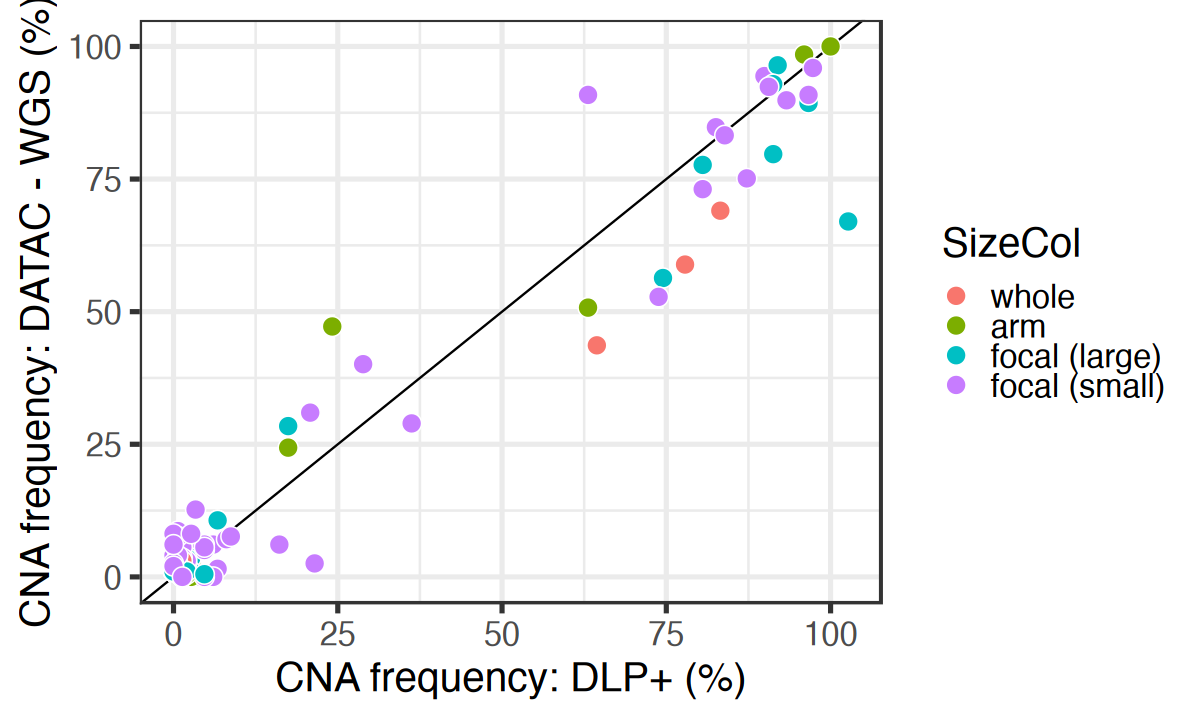

In [16]:
merged_df$SizeCol <- factor(merged_df$SizeCol, levels = c("whole",
                                                          "arm",
                                                          "focal (large)",
                                                          "focal (small)"))
p <- ggplot(data = merged_df, aes(x = P_B*100, y = P_A*100, fill = SizeCol))+
  geom_abline(intercept = 0, slope = 1, color = "black")+
  geom_point(shape = 21, alpha = 1, color = "white",size = 5) +
  ylab("CNA frequency: DATAC - WGS (%)")+
  xlab("CNA frequency: DLP+ (%)")+
  theme_bw(base_size = 24)

options(repr.plot.width=10, repr.plot.height=6)
p

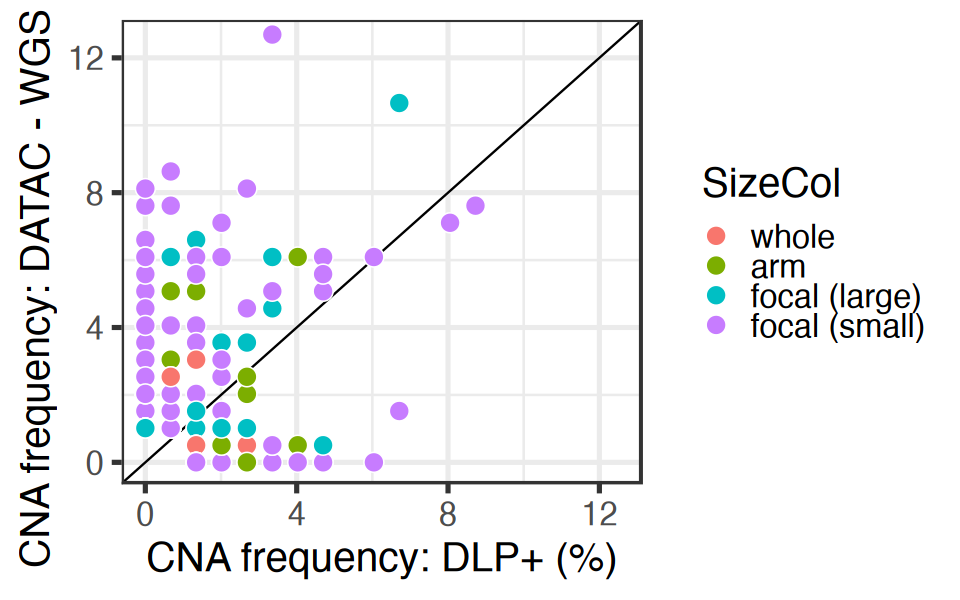

In [25]:
p <- ggplot(data = merged_df, aes(x = P_B*100, y = P_A*100, fill = SizeCol))+
  geom_abline(intercept = 0, slope = 1, color = "black")+
  geom_point(shape = 21, alpha = 1, color = "white",size = 5) +
  ylab("CNA frequency: DATAC - WGS (%)")+
  xlab("CNA frequency: DLP+ (%)")+
  coord_cartesian(xlim = c(0,12.5),
                  ylim = c(0,12.5))+
  theme_bw(base_size = 24)

options(repr.plot.width=8, repr.plot.height=5)
p

## Comparing unfiltered and filtered CNA heatmaps at each timepoint

In [62]:
# Import the metrics tables
metrics_pot <- data.frame(fread("../Data/CNA_Data/Raw/POTs_EP1_metrics.csv.gz")) 
metrics_pota <- data.frame(fread("../Data/CNA_Data/Raw/SW620_POTa_metrics.csv.gz")) 
metrics_potb <- data.frame(fread("../Data/CNA_Data/Raw/SW620_POTb_metrics.csv.gz"))
metrics_dsia <- data.frame(fread("../Data/CNA_Data/Raw/SW620_DSIa_metrics.csv.gz")) 
metrics_dsib <- data.frame(fread("../Data/CNA_Data/Raw/SW620_DSIb_metrics.csv.gz"))
metrics_dsiva <- data.frame(fread("../Data/CNA_Data/Raw/SW620_DSIVa_metrics.csv.gz")) 
metrics_dsivb <- data.frame(fread("../Data/CNA_Data/Raw/SW620_DSIVb_metrics.csv.gz"))
metrics_dt1a <- data.frame(fread("../Data/CNA_Data/Raw/SW620_DT1_P1a_metrics.csv.gz")) 
metrics_dt1b <- data.frame(fread("../Data/CNA_Data/Raw/SW620_DT1_P1b_metrics.csv.gz"))

metrics <- rbind(metrics_pot,
                 metrics_pota,
                 metrics_potb,
                 metrics_dsia ,
                 metrics_dsib,
                 metrics_dsiva,
                 metrics_dsivb,
                 metrics_dt1a,
                 metrics_dt1b)

# Import the cna data - unfiltered for min 1M reads
cnv_data_dlp_pot <- data.frame(fread("../Data/CNA_Data/Raw/QC/POTs_EP1_reads.csv.gz")) 
cnv_data_datac_pota <- data.frame(fread("../Data/CNA_Data/Raw/QC/SW620_POTa_reads.csv.gz")) 
cnv_data_datac_potb <- data.frame(fread("../Data/CNA_Data/Raw/QC/SW620_POTb_reads.csv.gz"))
cnv_data_datac_dsia <- data.frame(fread("../Data/CNA_Data/Raw/QC/SW620_DSIa_reads.csv.gz")) 
cnv_data_datac_dsib <- data.frame(fread("../Data/CNA_Data/Raw/QC/SW620_DSIb_reads.csv.gz"))
cnv_data_datac_dsiva <- data.frame(fread("../Data/CNA_Data/Raw/QC/SW620_DSIVa_reads.csv.gz")) 
cnv_data_datac_dsivb <- data.frame(fread("../Data/CNA_Data/Raw/QC/SW620_DSIVb_reads.csv.gz"))
cnv_data_datac_dt1a <- data.frame(fread("../Data/CNA_Data/Raw/QC/SW620_DT1_P1a_reads.csv.gz")) 
cnv_data_datac_dt1b <- data.frame(fread("../Data/CNA_Data/Raw/QC/SW620_DT1_P1b_reads.csv.gz"))

## T0

Warning message:
“There was 1 warning in `dplyr::arrange()`.
ℹ In argument: `..1 = as.numeric(chr)`.
Caused by warning:
! NAs introduced by coercion”


[1] "Total cells = 768"

Warning message:
“Setting row names on a tibble is deprecated.”
`use_raster` is automatically set to TRUE for a matrix with more than
2000 columns You can control `use_raster` argument by explicitly
setting TRUE/FALSE to it.

Set `ht_opt$message = FALSE` to turn off this message.



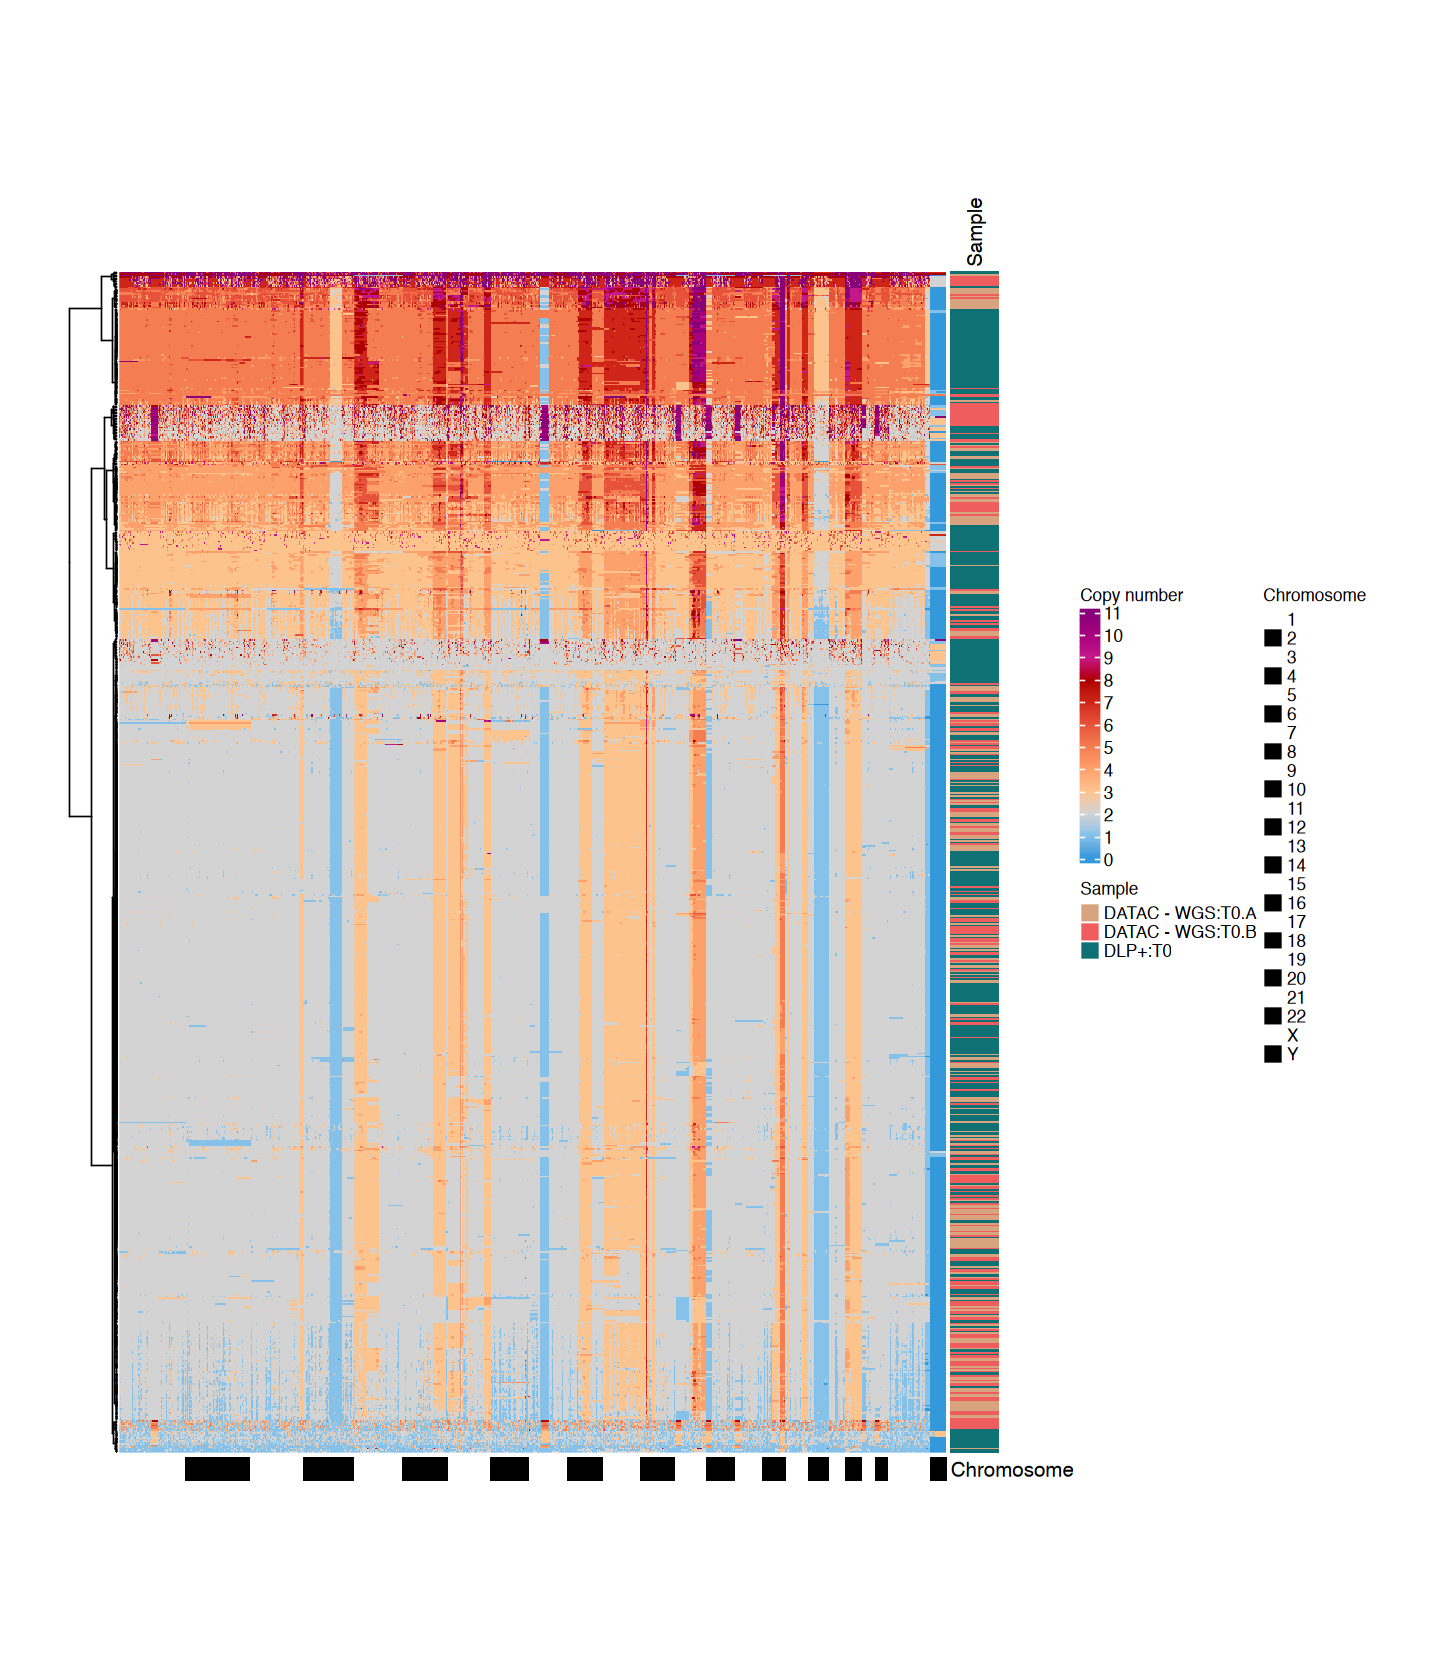

In [64]:
#1. unfiltered
# Format the CNV data 
cnv_data_fil <- rbind(cnv_data_dlp_pot,cnv_data_datac_pota,cnv_data_datac_potb) %>% dplyr::mutate(Location = sprintf("%s:%s-%s",chr,start,end)) %>%
  dplyr::arrange(as.numeric(chr)) %>% 
  dplyr::mutate_at("cell_id",str_replace,"-SW620bc_POTa|-SW620_POTb|-POTs_EP1","") %>%
  dplyr::select(cell_id,chr,start,end,state)

colnames(cnv_data_fil) <- c("cell_id","chrom","start","end","state")
sprintf("Total cells = %s",length(unique(cnv_data_fil$cell_id)))

##### --------------------  Plot the CNA heatmap ------------------- #####

# Add genomic position information
cna_data <- cnv_data_fil %>% dplyr::mutate(Location = sprintf("%s:%s-%s",chrom,start,end))

# Format cna data for heatmap plot
cna_df <- cna_data[,c("cell_id","state","Location")] %>% tidyr::pivot_wider(names_from = Location,
                                                                            values_from = `state`)
rownames(cna_df) <- cna_df$cell_id

cna_mat <- as.matrix(cna_df[,-1])
rownames(cna_mat) <- rownames(cna_df)

sample <- unlist(str_split(rownames(cna_df),"_DATAC|_DLP"))[seq(1,2*nrow(cna_df),2)]
sample[grep("POTm",sample)] <- "DATAC - WGS:T0.A"
sample[grep("POTp",sample)] <- "DATAC - WGS:T0.B"
sample[grep("POTs",sample)] <- "DLP+:T0"

sample <- factor(sample,levels = c("DATAC - WGS:T0.A","DATAC - WGS:T0.B","DLP+:T0"))

row_annotation_r <- data.frame(sample)
colnames(row_annotation_r) <- c("Sample")
rownames(row_annotation_r) <- rownames(cna_df)


row_annotation_r_h <- ComplexHeatmap::rowAnnotation(df = row_annotation_r,
                                                    col = list(`Sample` =  c("DATAC - WGS:T0.A" = "#d8a47f",
                                                                              "DATAC - WGS:T0.B" = "#f05d5e",
                                                                              "DLP+:T0" =  "#0f7173")),
                                                    simple_anno_size = unit(1, "cm"),
                                                    annotation_name_side = "top"
)


# Column annotation to separate chromosomes, listed in order 1,2,3,...,22,X
column_annotation <- data.frame(unlist(strsplit(colnames(cna_mat), split=':', fixed=TRUE))[seq(1,length(colnames(cna_mat))*2,by=2)])
colnames(column_annotation) <- "Chromosome"
rownames(column_annotation) <- colnames(cna_mat)
column_annotation$Chromosome <- factor(column_annotation$Chromosome, levels = c(sprintf("%s",c(1:22)),"X","Y"))

column_annotation_h <- ComplexHeatmap::HeatmapAnnotation(df = column_annotation,
                                                         col = list(Chromosome = c("1"="white", "2"="black", "3"="white", "4"="black",
                                                                                   "5"="white", "6"="black","7"="white", "8"="black",
                                                                                   "9"="white", "10"="black","11"="white", "12"="black",
                                                                                   "13"="white", "14"="black","15"="white", "16"="black",
                                                                                   "17"="white", "18"="black","19"="white", "20"="black",
                                                                                   "21"="white", "22"="black","X"="white","Y"="black") ),
                                                         simple_anno_size = unit(0.5, "cm")
)

# Define heatmap colours

myColor <- c("#3399db","#85c1e9","#d3d3d3","#fdc38d","#fda16c","#f57d52",
             "#e7523a","#cf2518","#ad0000","#c4188a","#a7007c","#87027a")
myBreaks <- seq(0,11,1)

colours <- circlize::colorRamp2(myBreaks,myColor) 


# Plot heatmap
h <- ComplexHeatmap::Heatmap(as.matrix(cna_mat), 
                             col = colours,
                             bottom_annotation = column_annotation_h,
                             right_annotation = row_annotation_r_h,
                             cluster_columns = F,
                             cluster_rows = T,
                             clustering_distance_rows = "manhattan",
                             clustering_method_rows = "ward.D2",
                             show_column_names = FALSE,
                             show_row_names =F,
                             heatmap_legend_param = list(title = "Copy number",
                                                         at = myBreaks),
                             raster_quality = 10,
                             width = unit(17.5,"cm"),
                             height = unit(25,"cm"))


options(repr.plot.width=12, repr.plot.height=14)
ComplexHeatmap::draw(h, heatmap_legend_side="right", annotation_legend_side="right")


Warning message:
“There was 1 warning in `dplyr::arrange()`.
ℹ In argument: `..1 = as.numeric(chr)`.
Caused by warning:
! NAs introduced by coercion”


[1] "Total cells = 357"

Warning message:
“Setting row names on a tibble is deprecated.”
`use_raster` is automatically set to TRUE for a matrix with more than
2000 columns You can control `use_raster` argument by explicitly
setting TRUE/FALSE to it.

Set `ht_opt$message = FALSE` to turn off this message.



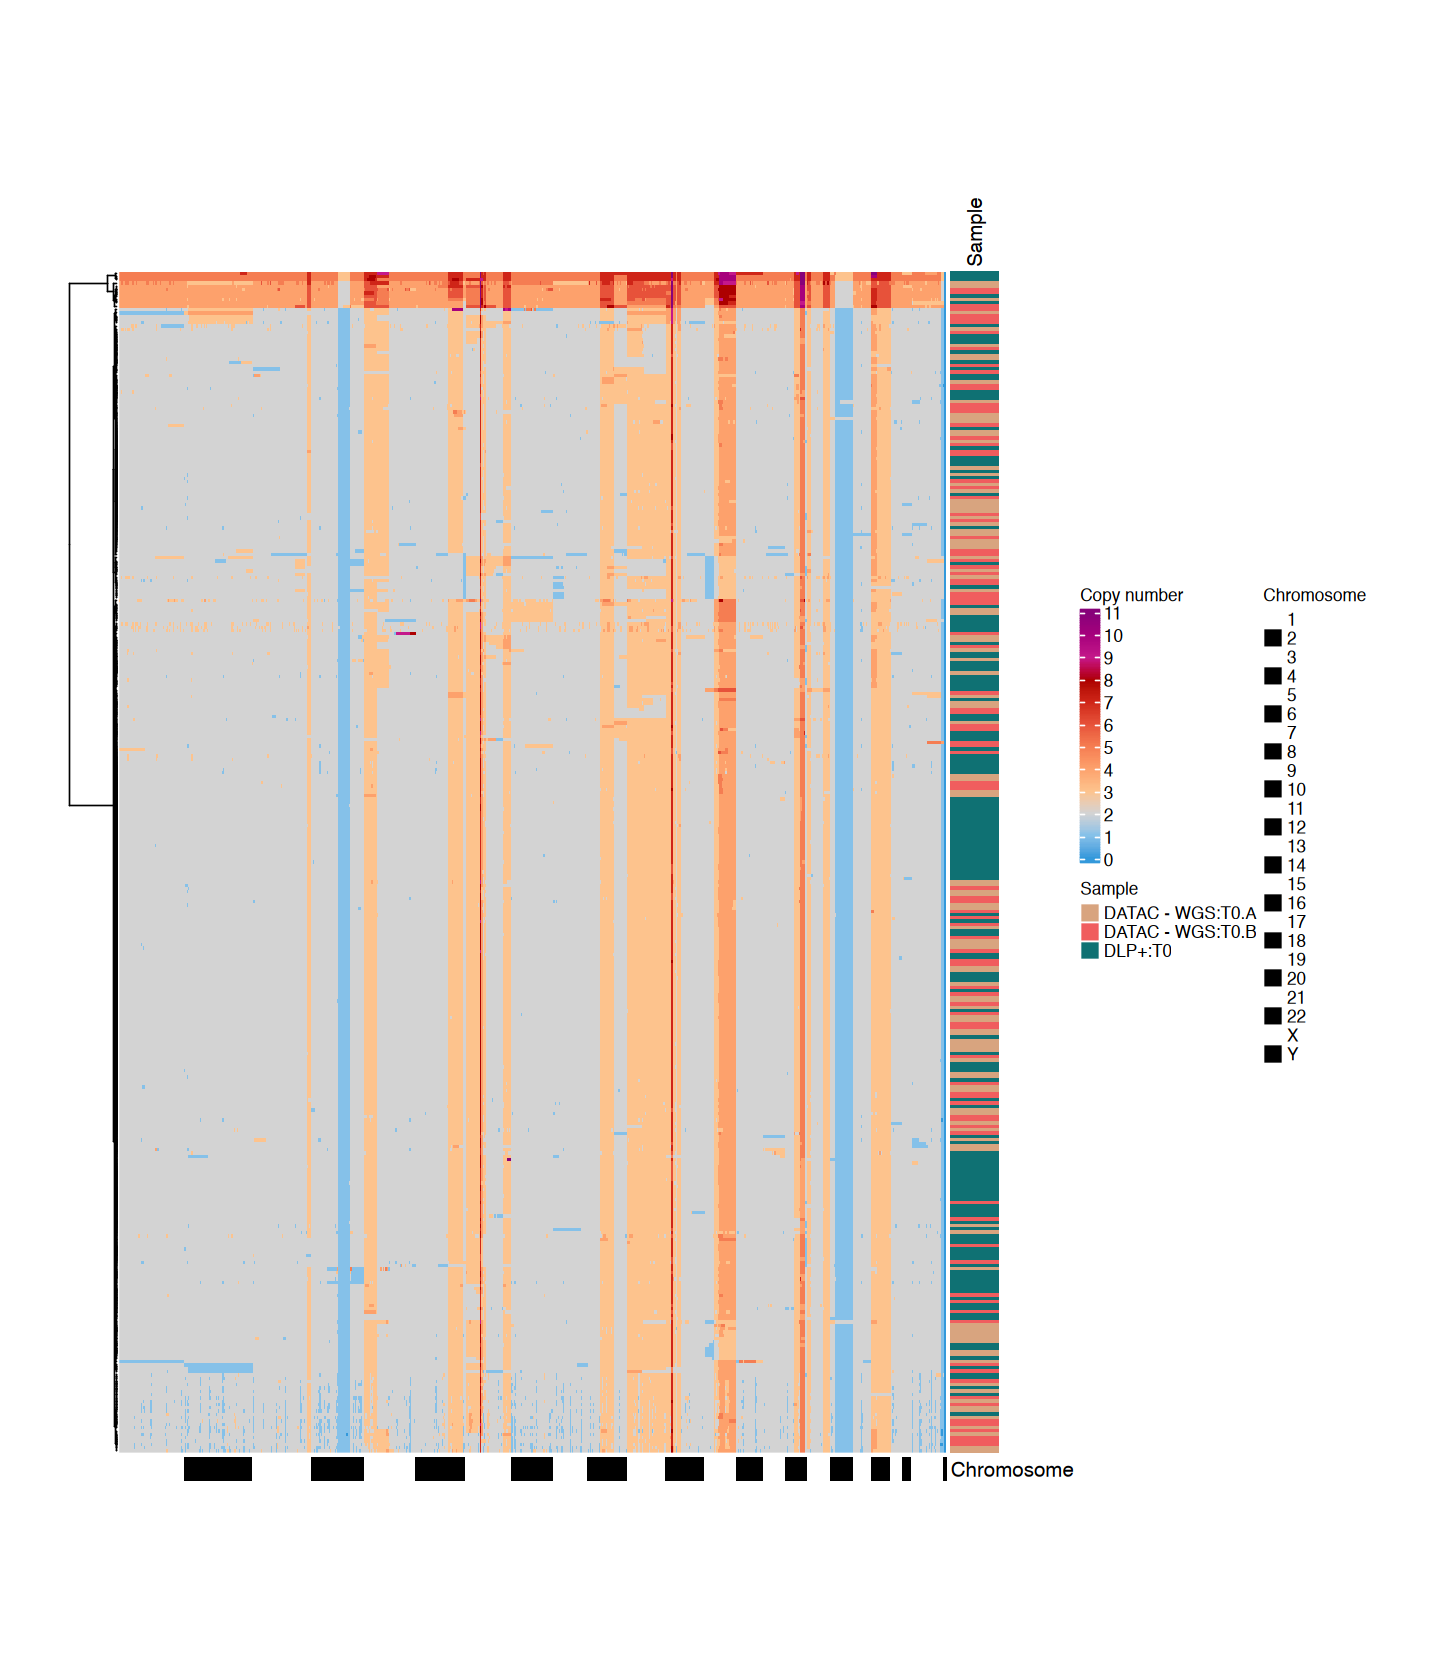

In [65]:
#2. filtered
# Format the CNV data 
cnv_data_fil <- rbind(cnv_data_dlp_pot,cnv_data_datac_pota,cnv_data_datac_potb) %>% dplyr::mutate(Location = sprintf("%s:%s-%s",chr,start,end)) %>%
  dplyr::arrange(as.numeric(chr)) %>% 
  dplyr::filter(cell_id %in% metrics[metrics$quality > 0.75 & metrics$is_s_phase == F & metrics$total_mapped_reads_hmmcopy >= 1000000,]$cell_id) %>% 
  dplyr::filter(map > 0.99) %>%
  dplyr::mutate_at("cell_id",str_replace,"-SW620bc_POTa|-SW620_POTb|-POTs_EP1","") %>%
  dplyr::select(cell_id,chr,start,end,state)

colnames(cnv_data_fil) <- c("cell_id","chrom","start","end","state")
sprintf("Total cells = %s",length(unique(cnv_data_fil$cell_id)))

##### --------------------  Plot the CNA heatmap ------------------- #####

# Add genomic position information
cna_data <- cnv_data_fil %>% dplyr::mutate(Location = sprintf("%s:%s-%s",chrom,start,end))

# Format cna data for heatmap plot
cna_df <- cna_data[,c("cell_id","state","Location")] %>% tidyr::pivot_wider(names_from = Location,
                                                                            values_from = `state`)
rownames(cna_df) <- cna_df$cell_id

cna_mat <- as.matrix(cna_df[,-1])
rownames(cna_mat) <- rownames(cna_df)

sample <- unlist(str_split(rownames(cna_df),"_DATAC|_DLP"))[seq(1,2*nrow(cna_df),2)]
sample[grep("POTm",sample)] <- "DATAC - WGS:T0.A"
sample[grep("POTp",sample)] <- "DATAC - WGS:T0.B"
sample[grep("POTs",sample)] <- "DLP+:T0"

sample <- factor(sample,levels = c("DATAC - WGS:T0.A","DATAC - WGS:T0.B","DLP+:T0"))

row_annotation_r <- data.frame(sample)
colnames(row_annotation_r) <- c("Sample")
rownames(row_annotation_r) <- rownames(cna_df)


row_annotation_r_h <- ComplexHeatmap::rowAnnotation(df = row_annotation_r,
                                                    col = list(`Sample` =  c("DATAC - WGS:T0.A" = "#d8a47f",
                                                                              "DATAC - WGS:T0.B" = "#f05d5e",
                                                                              "DLP+:T0" =  "#0f7173")),
                                                    simple_anno_size = unit(1, "cm"),
                                                    annotation_name_side = "top"
)


# Column annotation to separate chromosomes, listed in order 1,2,3,...,22,X
column_annotation <- data.frame(unlist(strsplit(colnames(cna_mat), split=':', fixed=TRUE))[seq(1,length(colnames(cna_mat))*2,by=2)])
colnames(column_annotation) <- "Chromosome"
rownames(column_annotation) <- colnames(cna_mat)
column_annotation$Chromosome <- factor(column_annotation$Chromosome, levels = c(sprintf("%s",c(1:22)),"X","Y"))

column_annotation_h <- ComplexHeatmap::HeatmapAnnotation(df = column_annotation,
                                                         col = list(Chromosome = c("1"="white", "2"="black", "3"="white", "4"="black",
                                                                                   "5"="white", "6"="black","7"="white", "8"="black",
                                                                                   "9"="white", "10"="black","11"="white", "12"="black",
                                                                                   "13"="white", "14"="black","15"="white", "16"="black",
                                                                                   "17"="white", "18"="black","19"="white", "20"="black",
                                                                                   "21"="white", "22"="black","X"="white","Y"="black") ),
                                                         simple_anno_size = unit(0.5, "cm")
)

# Define heatmap colours

myColor <- c("#3399db","#85c1e9","#d3d3d3","#fdc38d","#fda16c","#f57d52",
             "#e7523a","#cf2518","#ad0000","#c4188a","#a7007c","#87027a")
myBreaks <- seq(0,11,1)

colours <- circlize::colorRamp2(myBreaks,myColor) 


# Plot heatmap
h <- ComplexHeatmap::Heatmap(as.matrix(cna_mat), 
                             col = colours,
                             bottom_annotation = column_annotation_h,
                             right_annotation = row_annotation_r_h,
                             cluster_columns = F,
                             cluster_rows = T,
                             clustering_distance_rows = "manhattan",
                             clustering_method_rows = "ward.D2",
                             show_column_names = FALSE,
                             show_row_names =F,
                             heatmap_legend_param = list(title = "Copy number",
                                                         at = myBreaks),
                             raster_quality = 10,
                             width = unit(17.5,"cm"),
                             height = unit(25,"cm"))


options(repr.plot.width=12, repr.plot.height=14)
ComplexHeatmap::draw(h, heatmap_legend_side="right", annotation_legend_side="right")


### T1

Warning message:
“There was 1 warning in `dplyr::arrange()`.
ℹ In argument: `..1 = as.numeric(chr)`.
Caused by warning:
! NAs introduced by coercion”


[1] "Total cells = 384"

Warning message:
“Setting row names on a tibble is deprecated.”
`use_raster` is automatically set to TRUE for a matrix with more than
2000 columns You can control `use_raster` argument by explicitly
setting TRUE/FALSE to it.

Set `ht_opt$message = FALSE` to turn off this message.



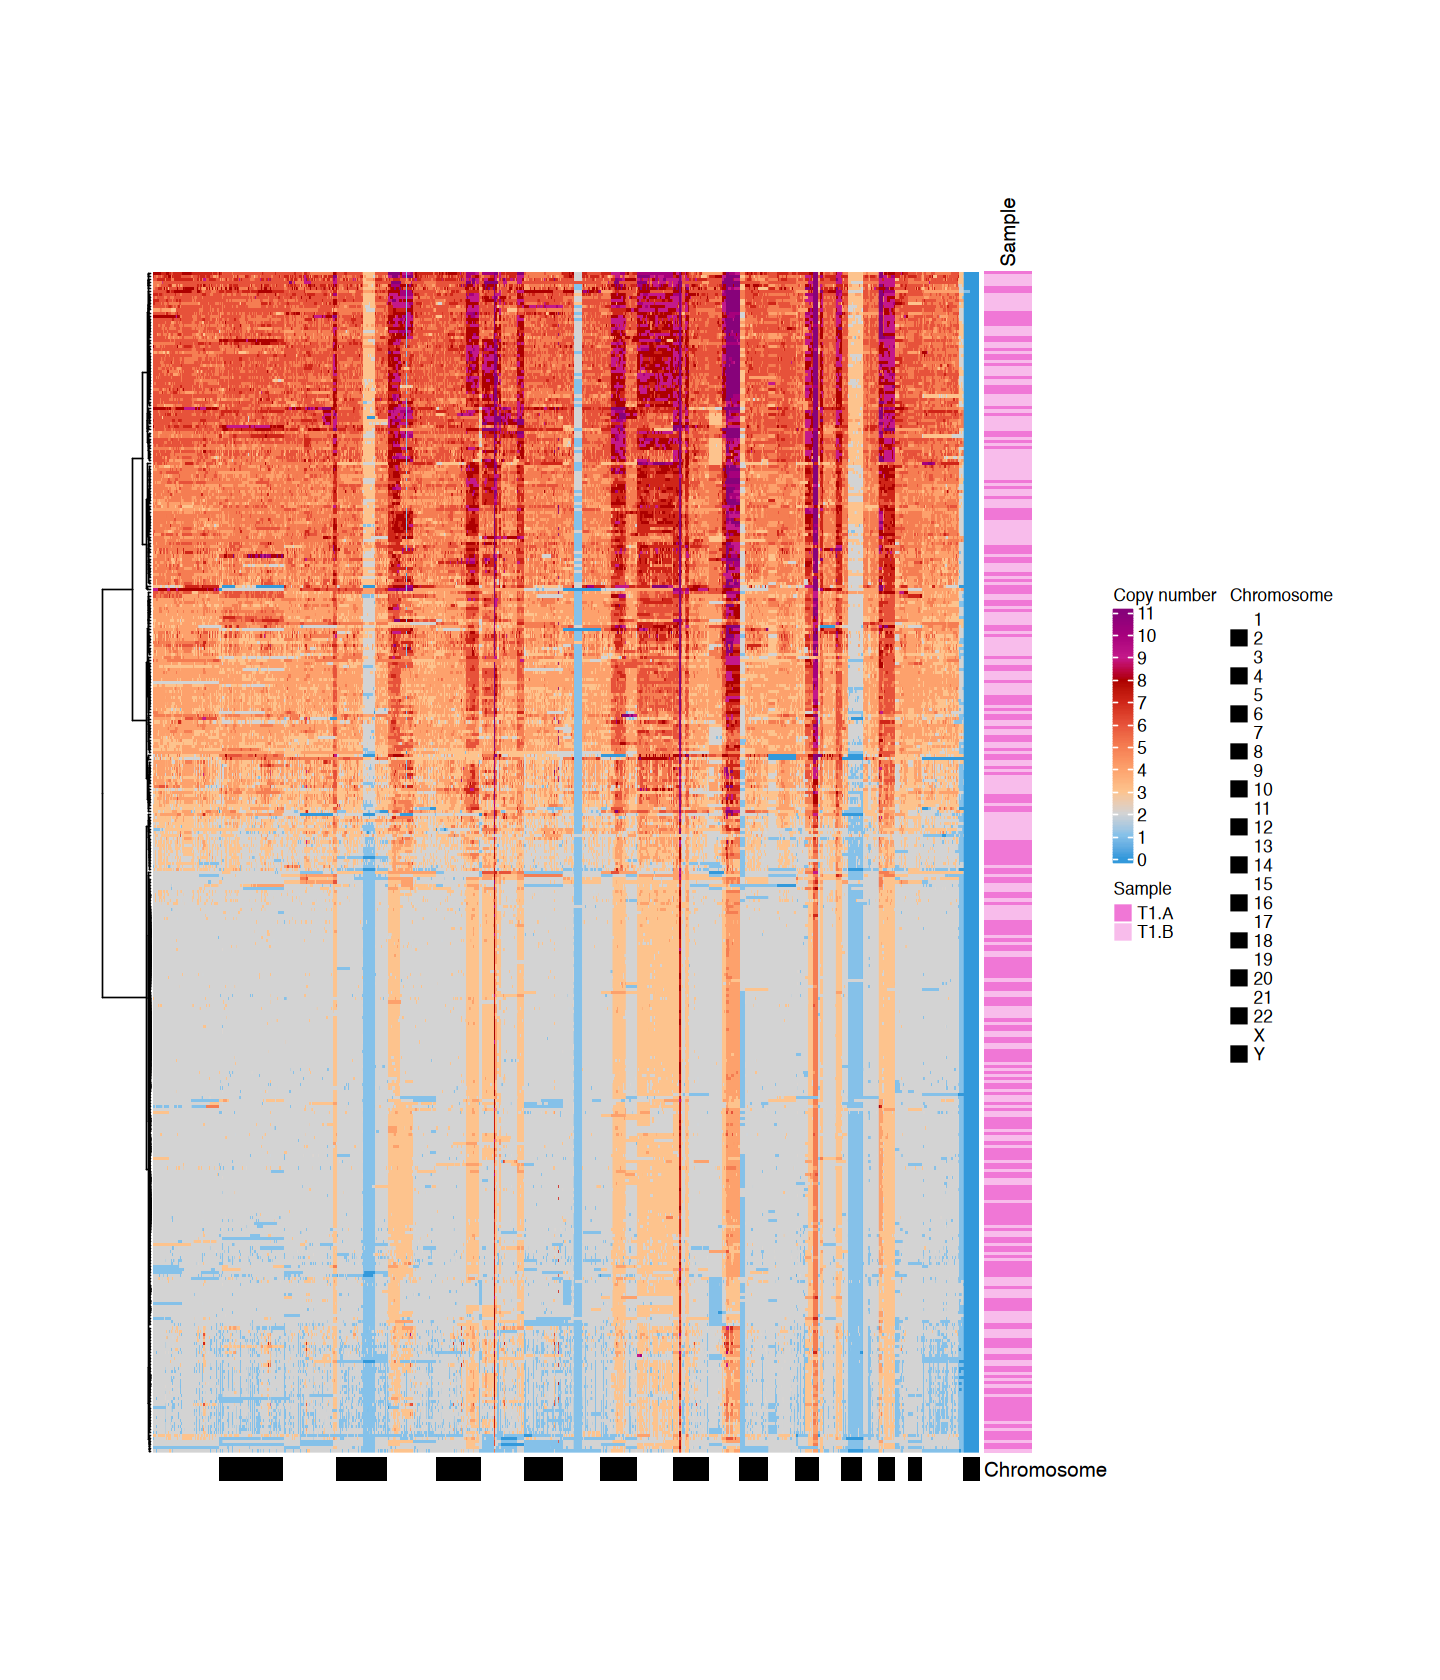

In [67]:
#1. unfiltered
# Format the CNV data 
cnv_data_fil <- rbind(cnv_data_datac_dsia,cnv_data_datac_dsib) %>% dplyr::mutate(Location = sprintf("%s:%s-%s",chr,start,end)) %>%
  dplyr::arrange(as.numeric(chr)) %>% 
  dplyr::mutate_at("cell_id",str_replace,"-SW620_DSIa|-SW620bc_DSIb","") %>%
  dplyr::select(cell_id,chr,start,end,state)

colnames(cnv_data_fil) <- c("cell_id","chrom","start","end","state")
sprintf("Total cells = %s",length(unique(cnv_data_fil$cell_id)))

##### --------------------  Plot the CNA heatmap ------------------- #####

# Add genomic position information
cna_data <- cnv_data_fil %>% dplyr::mutate(Location = sprintf("%s:%s-%s",chrom,start,end))

# Format cna data for heatmap plot
cna_df <- cna_data[,c("cell_id","state","Location")] %>% tidyr::pivot_wider(names_from = Location,
                                                                            values_from = `state`)
rownames(cna_df) <- cna_df$cell_id

cna_mat <- as.matrix(cna_df[,-1])
rownames(cna_mat) <- rownames(cna_df)


sample <- unlist(str_split(rownames(cna_df),"_DATAC"))[seq(1,2*nrow(cna_df),2)]
sample[grep("DSIa",sample)] <- "T1.A"
sample[grep("DSIb",sample)] <- "T1.B"


row_annotation_r <- data.frame(sample)
colnames(row_annotation_r) <- c("Sample")
rownames(row_annotation_r) <- rownames(cna_df)


row_annotation_r_h <- ComplexHeatmap::rowAnnotation(df = row_annotation_r,
                                                    col = list( `Sample` =  c("T1.A" =  "#f077d6",
                                                                              "T1.B" =  "#f8bceb")),
                                                    simple_anno_size = unit(1, "cm"),
                                                    annotation_name_side = "top"
)


# Column annotation to separate chromosomes, listed in order 1,2,3,...,22,X
column_annotation <- data.frame(unlist(strsplit(colnames(cna_mat), split=':', fixed=TRUE))[seq(1,length(colnames(cna_mat))*2,by=2)])
colnames(column_annotation) <- "Chromosome"
rownames(column_annotation) <- colnames(cna_mat)
column_annotation$Chromosome <- factor(column_annotation$Chromosome, levels = c(sprintf("%s",c(1:22)),"X","Y"))

column_annotation_h <- ComplexHeatmap::HeatmapAnnotation(df = column_annotation,
                                                         col = list(Chromosome = c("1"="white", "2"="black", "3"="white", "4"="black",
                                                                                   "5"="white", "6"="black","7"="white", "8"="black",
                                                                                   "9"="white", "10"="black","11"="white", "12"="black",
                                                                                   "13"="white", "14"="black","15"="white", "16"="black",
                                                                                   "17"="white", "18"="black","19"="white", "20"="black",
                                                                                   "21"="white", "22"="black","X"="white","Y"="black") ),
                                                         simple_anno_size = unit(0.5, "cm")
)

# Define heatmap colours

myColor <- c("#3399db","#85c1e9","#d3d3d3","#fdc38d","#fda16c","#f57d52",
             "#e7523a","#cf2518","#ad0000","#c4188a","#a7007c","#87027a")
myBreaks <- seq(0,11,1)

colours <- circlize::colorRamp2(myBreaks,myColor) 


# Plot heatmap
h <- ComplexHeatmap::Heatmap(as.matrix(cna_mat), 
                             col = colours,
                             bottom_annotation = column_annotation_h,
                             right_annotation = row_annotation_r_h,
                             cluster_columns = F,
                             cluster_rows = T,
                             clustering_distance_rows = "manhattan",
                             clustering_method_rows = "ward.D2",
                             show_column_names = FALSE,
                             show_row_names =F,
                             heatmap_legend_param = list(title = "Copy number",
                                                         at = myBreaks),
                             raster_quality = 10,
                             width = unit(17.5,"cm"),
                             height = unit(25,"cm"))


options(repr.plot.width=12, repr.plot.height=14)
ComplexHeatmap::draw(h, heatmap_legend_side="right", annotation_legend_side="right")


Warning message:
“There was 1 warning in `dplyr::arrange()`.
ℹ In argument: `..1 = as.numeric(chr)`.
Caused by warning:
! NAs introduced by coercion”


[1] "Total cells = 129"

Warning message:
“Setting row names on a tibble is deprecated.”
`use_raster` is automatically set to TRUE for a matrix with more than
2000 columns You can control `use_raster` argument by explicitly
setting TRUE/FALSE to it.

Set `ht_opt$message = FALSE` to turn off this message.



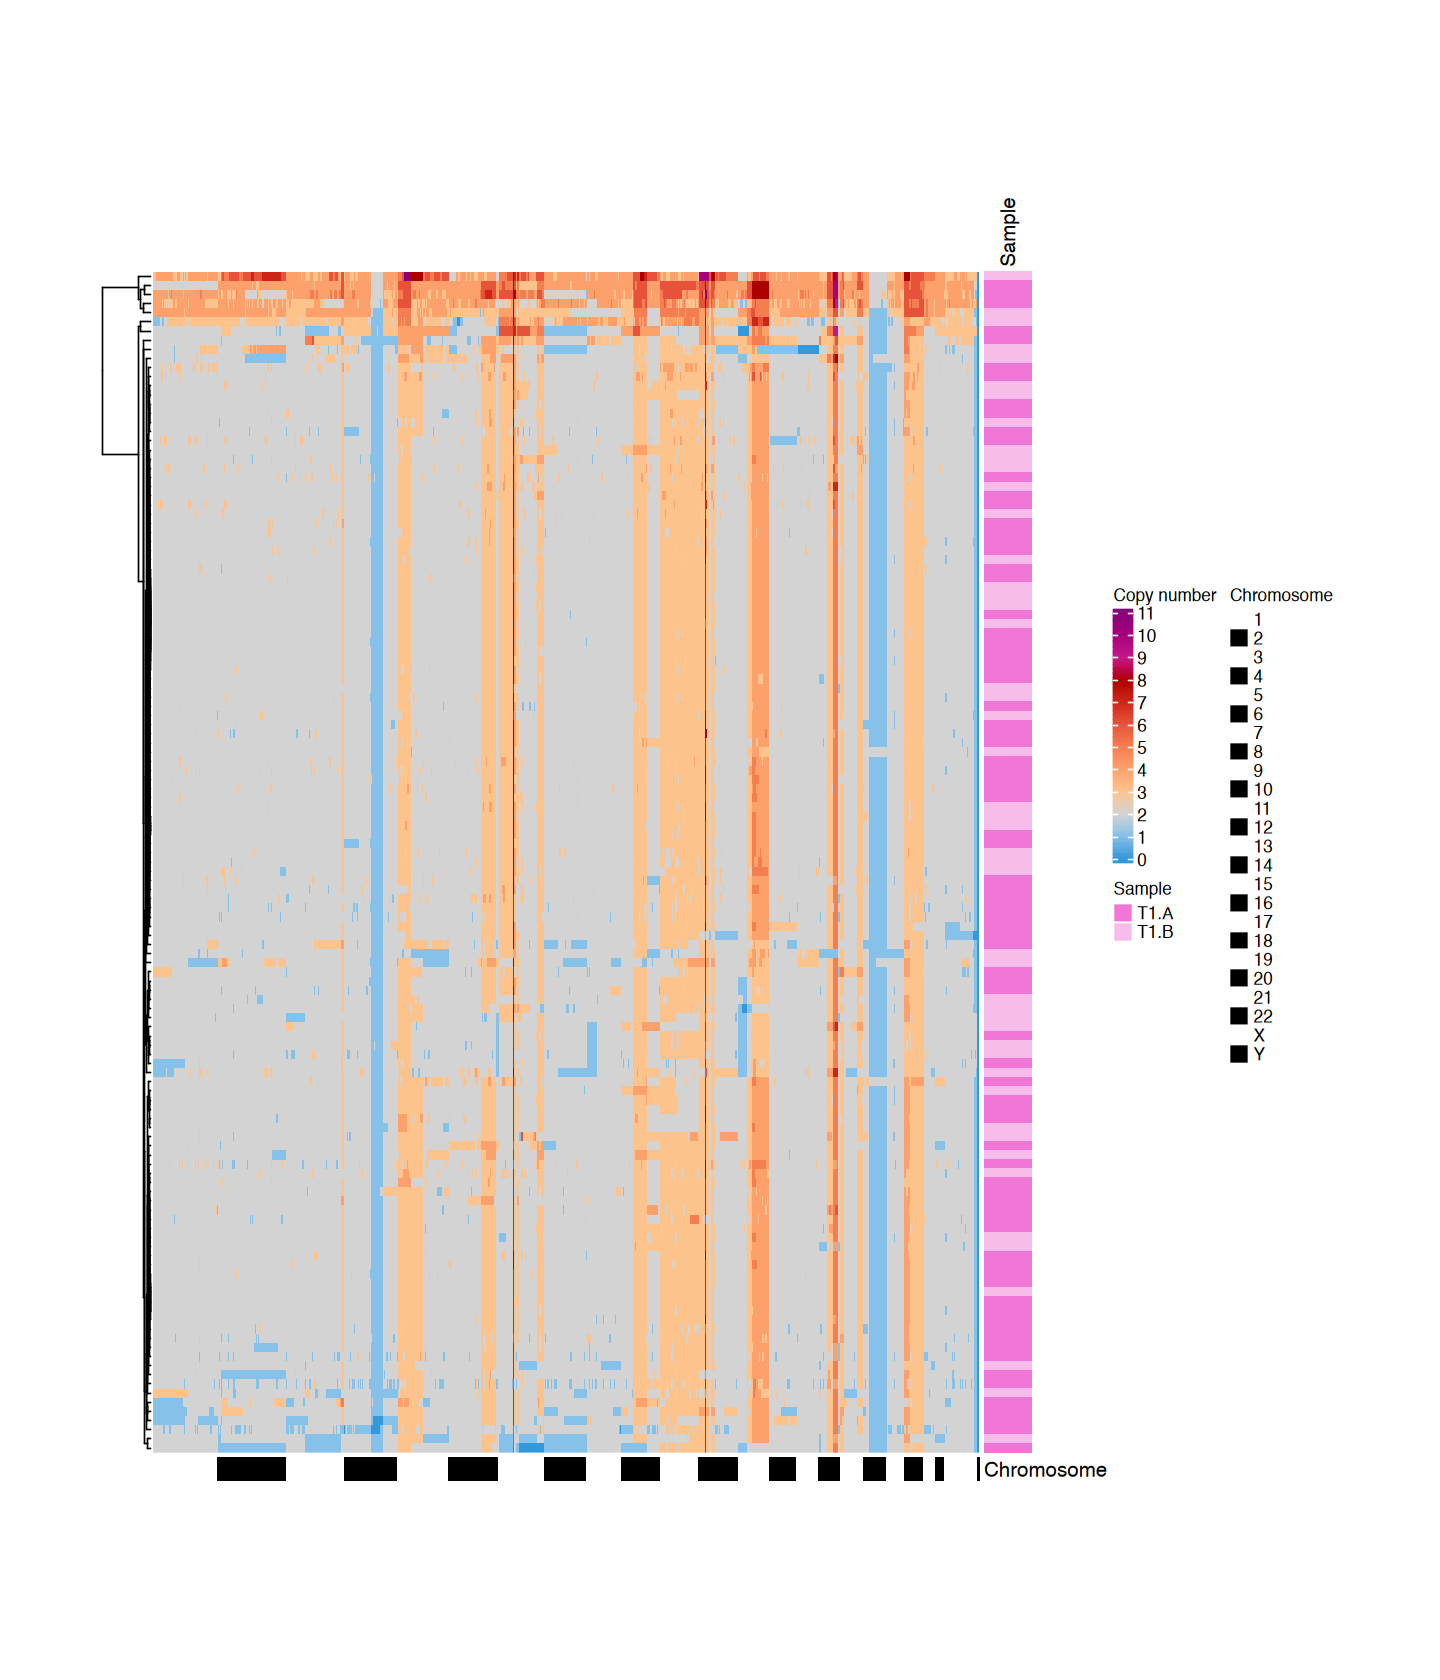

In [68]:
## 2. filtered

# Format the CNV data 
cnv_data_fil <- rbind(cnv_data_datac_dsia,cnv_data_datac_dsib) %>% dplyr::mutate(Location = sprintf("%s:%s-%s",chr,start,end)) %>%
  dplyr::arrange(as.numeric(chr)) %>% 
  dplyr::filter(cell_id %in% metrics[metrics$quality > 0.75 & metrics$is_s_phase == F & metrics$total_mapped_reads_hmmcopy >= 1000000,]$cell_id) %>% 
  dplyr::filter(map > 0.99) %>%
  dplyr::mutate_at("cell_id",str_replace,"-SW620bc_DSIa|-SW620_DSIb","") %>%
  dplyr::select(cell_id,chr,start,end,state)

colnames(cnv_data_fil) <- c("cell_id","chrom","start","end","state")
sprintf("Total cells = %s",length(unique(cnv_data_fil$cell_id)))

##### --------------------  Plot the CNA heatmap ------------------- #####

# Add genomic position information
cna_data <- cnv_data_fil %>% dplyr::mutate(Location = sprintf("%s:%s-%s",chrom,start,end))

# Format cna data for heatmap plot
cna_df <- cna_data[,c("cell_id","state","Location")] %>% tidyr::pivot_wider(names_from = Location,
                                                                            values_from = `state`)
rownames(cna_df) <- cna_df$cell_id

cna_mat <- as.matrix(cna_df[,-1])
rownames(cna_mat) <- rownames(cna_df)


sample <- unlist(str_split(rownames(cna_df),"_DATAC"))[seq(1,2*nrow(cna_df),2)]
sample[grep("DSIa",sample)] <- "T1.A"
sample[grep("DSIb",sample)] <- "T1.B"


row_annotation_r <- data.frame(sample)
colnames(row_annotation_r) <- c("Sample")
rownames(row_annotation_r) <- rownames(cna_df)


row_annotation_r_h <- ComplexHeatmap::rowAnnotation(df = row_annotation_r,
                                                    col = list( `Sample` =  c("T1.A" =  "#f077d6",
                                                                              "T1.B" =  "#f8bceb")),
                                                    simple_anno_size = unit(1, "cm"),
                                                    annotation_name_side = "top"
)


# Column annotation to separate chromosomes, listed in order 1,2,3,...,22,X
column_annotation <- data.frame(unlist(strsplit(colnames(cna_mat), split=':', fixed=TRUE))[seq(1,length(colnames(cna_mat))*2,by=2)])
colnames(column_annotation) <- "Chromosome"
rownames(column_annotation) <- colnames(cna_mat)
column_annotation$Chromosome <- factor(column_annotation$Chromosome, levels = c(sprintf("%s",c(1:22)),"X","Y"))

column_annotation_h <- ComplexHeatmap::HeatmapAnnotation(df = column_annotation,
                                                         col = list(Chromosome = c("1"="white", "2"="black", "3"="white", "4"="black",
                                                                                   "5"="white", "6"="black","7"="white", "8"="black",
                                                                                   "9"="white", "10"="black","11"="white", "12"="black",
                                                                                   "13"="white", "14"="black","15"="white", "16"="black",
                                                                                   "17"="white", "18"="black","19"="white", "20"="black",
                                                                                   "21"="white", "22"="black","X"="white","Y"="black") ),
                                                         simple_anno_size = unit(0.5, "cm")
)

# Define heatmap colours

myColor <- c("#3399db","#85c1e9","#d3d3d3","#fdc38d","#fda16c","#f57d52",
             "#e7523a","#cf2518","#ad0000","#c4188a","#a7007c","#87027a")
myBreaks <- seq(0,11,1)

colours <- circlize::colorRamp2(myBreaks,myColor) 


# Plot heatmap
h <- ComplexHeatmap::Heatmap(as.matrix(cna_mat), 
                             col = colours,
                             bottom_annotation = column_annotation_h,
                             right_annotation = row_annotation_r_h,
                             cluster_columns = F,
                             cluster_rows = T,
                             clustering_distance_rows = "manhattan",
                             clustering_method_rows = "ward.D2",
                             show_column_names = FALSE,
                             show_row_names =F,
                             heatmap_legend_param = list(title = "Copy number",
                                                         at = myBreaks),
                             raster_quality = 10,
                             width = unit(17.5,"cm"),
                             height = unit(25,"cm"))

options(repr.plot.width=12, repr.plot.height=14)
ComplexHeatmap::draw(h, heatmap_legend_side="right", annotation_legend_side="right")

## T4

Warning message:
“There was 1 warning in `dplyr::arrange()`.
ℹ In argument: `..1 = as.numeric(chr)`.
Caused by warning:
! NAs introduced by coercion”


[1] 768

[1] "Total cells = 768"

Warning message:
“Setting row names on a tibble is deprecated.”
`use_raster` is automatically set to TRUE for a matrix with more than
2000 columns You can control `use_raster` argument by explicitly
setting TRUE/FALSE to it.

Set `ht_opt$message = FALSE` to turn off this message.



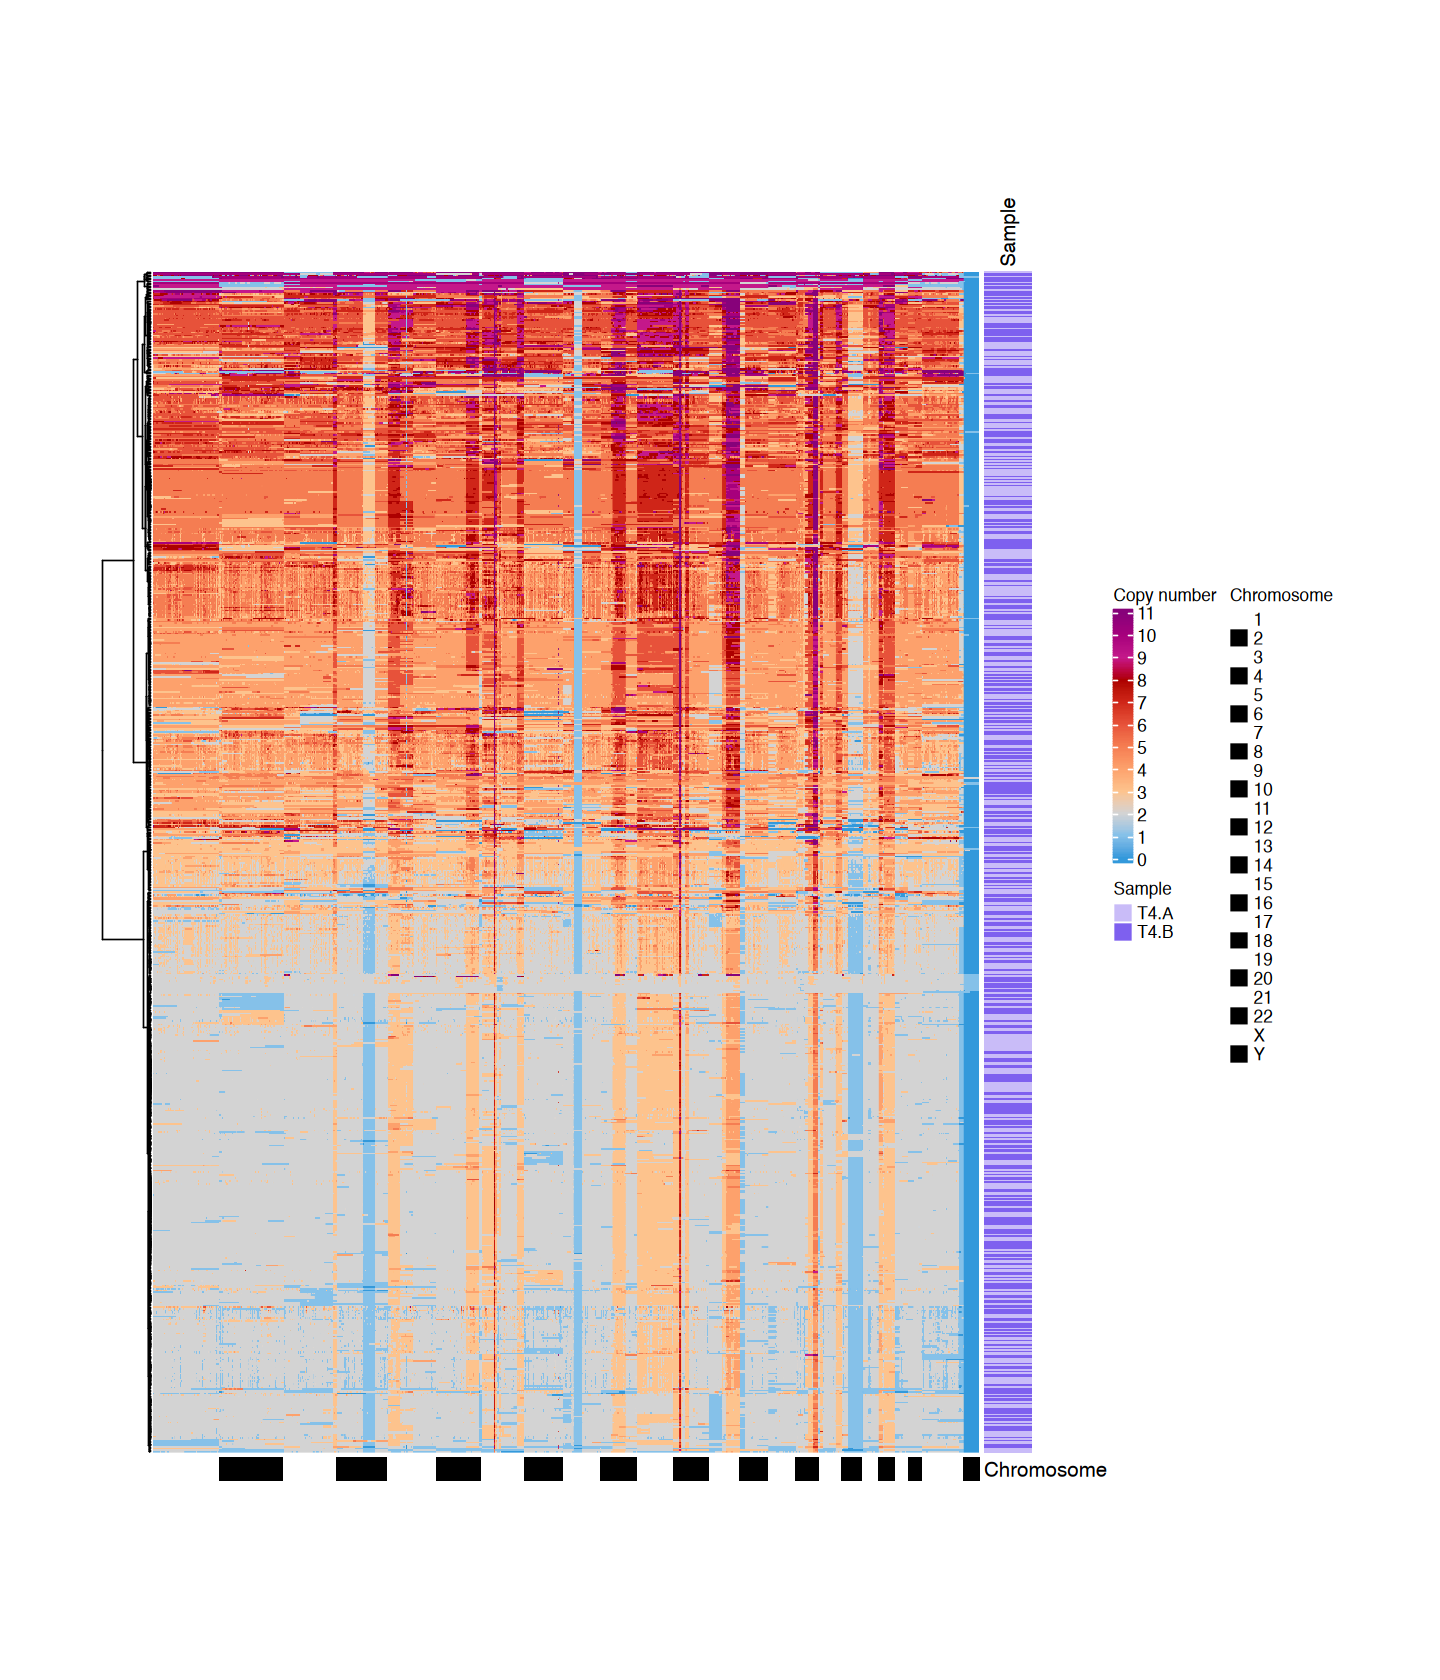

In [36]:
# Format the CNV data 
cnv_data_fil <- rbind(cnv_data_datac_dsiva,cnv_data_datac_dsivb) %>% dplyr::mutate(Location = sprintf("%s:%s-%s",chr,start,end)) %>%
  dplyr::arrange(as.numeric(chr)) %>% 
  dplyr::mutate_at("cell_id",str_replace,"-SW620bc_DSIVa|-SW620_DSIVb","") %>%
  dplyr::select(cell_id,chr,start,end,state)

colnames(cnv_data_fil) <- c("cell_id","chrom","start","end","state")
length(unique(cnv_data_fil$cell_id))
sprintf("Total cells = %s",length(unique(cnv_data_fil$cell_id)))

##### --------------------  Plot the CNA heatmap ------------------- #####

# Add genomic position information
cna_data <- cnv_data_fil %>% dplyr::mutate(Location = sprintf("%s:%s-%s",chrom,start,end))

# Format cna data for heatmap plot
cna_df <- cna_data[,c("cell_id","state","Location")] %>% tidyr::pivot_wider(names_from = Location,
                                                                            values_from = `state`)
rownames(cna_df) <- cna_df$cell_id

cna_mat <- as.matrix(cna_df[,-1])
rownames(cna_mat) <- rownames(cna_df)


sample <- unlist(str_split(rownames(cna_df),"_DATAC"))[seq(1,2*nrow(cna_df),2)]
sample[grep("DSIVa",sample)] <- "T4.A"
sample[grep("DSIVb",sample)] <- "T4.B"


row_annotation_r <- data.frame(sample)
colnames(row_annotation_r) <- c("Sample")
rownames(row_annotation_r) <- rownames(cna_df)


row_annotation_r_h <- ComplexHeatmap::rowAnnotation(df = row_annotation_r,
                                                    col = list( `Sample` =  c( "T4.A" = "#c9bcf8",
                                                                               "T4.B" = "#7e60ef")),
                                                    simple_anno_size = unit(1, "cm"),
                                                    annotation_name_side = "top"
)


# Column annotation to separate chromosomes, listed in order 1,2,3,...,22,X
column_annotation <- data.frame(unlist(strsplit(colnames(cna_mat), split=':', fixed=TRUE))[seq(1,length(colnames(cna_mat))*2,by=2)])
colnames(column_annotation) <- "Chromosome"
rownames(column_annotation) <- colnames(cna_mat)
column_annotation$Chromosome <- factor(column_annotation$Chromosome, levels = c(sprintf("%s",c(1:22)),"X","Y"))

column_annotation_h <- ComplexHeatmap::HeatmapAnnotation(df = column_annotation,
                                                         col = list(Chromosome = c("1"="white", "2"="black", "3"="white", "4"="black",
                                                                                   "5"="white", "6"="black","7"="white", "8"="black",
                                                                                   "9"="white", "10"="black","11"="white", "12"="black",
                                                                                   "13"="white", "14"="black","15"="white", "16"="black",
                                                                                   "17"="white", "18"="black","19"="white", "20"="black",
                                                                                   "21"="white", "22"="black","X"="white","Y"="black") ),
                                                         simple_anno_size = unit(0.5, "cm")
)

# Define heatmap colours

myColor <- c("#3399db","#85c1e9","#d3d3d3","#fdc38d","#fda16c","#f57d52",
             "#e7523a","#cf2518","#ad0000","#c4188a","#a7007c","#87027a")
myBreaks <- seq(0,11,1)

colours <- circlize::colorRamp2(myBreaks,myColor) 


# Plot heatmap
h <- ComplexHeatmap::Heatmap(as.matrix(cna_mat), 
                             col = colours,
                             bottom_annotation = column_annotation_h,
                             right_annotation = row_annotation_r_h,
                             cluster_columns = F,
                             cluster_rows = T,
                             clustering_distance_rows = "manhattan",
                             clustering_method_rows = "ward.D2",
                             show_column_names = FALSE,
                             show_row_names =F,
                             heatmap_legend_param = list(title = "Copy number",
                                                         at = myBreaks),
                             raster_quality = 10,
                             width = unit(17.5,"cm"),
                             height = unit(25,"cm"))

options(repr.plot.width=12, repr.plot.height=14)
ComplexHeatmap::draw(h, heatmap_legend_side="right", annotation_legend_side="right")

Warning message:
“There was 1 warning in `dplyr::arrange()`.
ℹ In argument: `..1 = as.numeric(chr)`.
Caused by warning:
! NAs introduced by coercion”


[1] "Total cells = 311"

Warning message:
“Setting row names on a tibble is deprecated.”
`use_raster` is automatically set to TRUE for a matrix with more than
2000 columns You can control `use_raster` argument by explicitly
setting TRUE/FALSE to it.

Set `ht_opt$message = FALSE` to turn off this message.



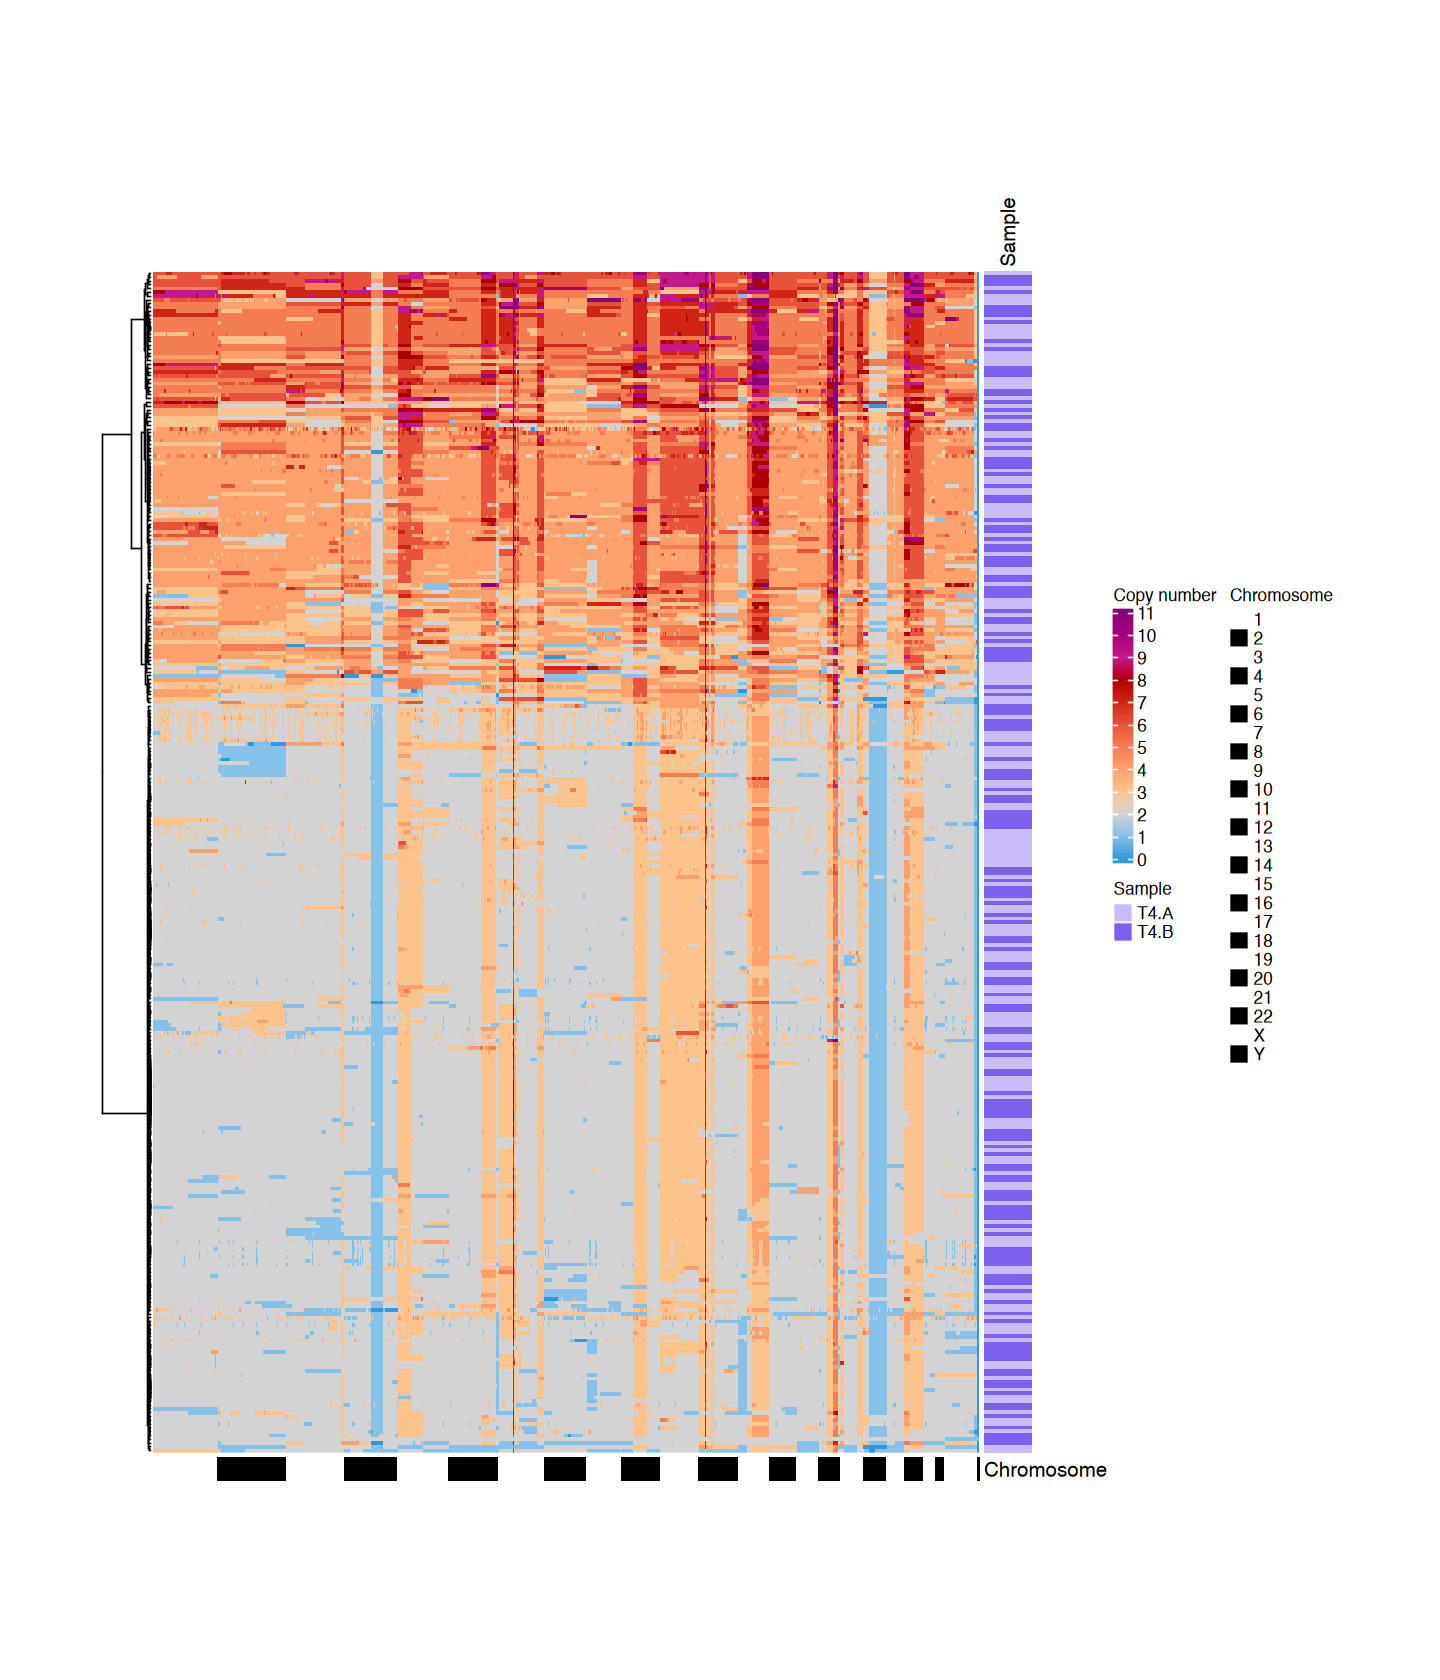

In [37]:
# Format the CNV data 
cnv_data_fil <- rbind(cnv_data_datac_dsiva,cnv_data_datac_dsivb) %>% dplyr::mutate(Location = sprintf("%s:%s-%s",chr,start,end)) %>%
  dplyr::arrange(as.numeric(chr)) %>% 
  dplyr::filter(cell_id %in% metrics[metrics$quality > 0.75 & metrics$is_s_phase == F & metrics$total_mapped_reads_hmmcopy >= 1000000,]$cell_id) %>% 
  dplyr::filter(map > 0.99) %>%
  dplyr::mutate_at("cell_id",str_replace,"-SW620bc_DSIVa|-SW620_DSIVb","") %>%
  dplyr::select(cell_id,chr,start,end,state)

colnames(cnv_data_fil) <- c("cell_id","chrom","start","end","state")

sprintf("Total cells = %s",length(unique(cnv_data_fil$cell_id)))

##### --------------------  Plot the CNA heatmap ------------------- #####

# Add genomic position information
cna_data <- cnv_data_fil %>% dplyr::mutate(Location = sprintf("%s:%s-%s",chrom,start,end))

# Format cna data for heatmap plot
cna_df <- cna_data[,c("cell_id","state","Location")] %>% tidyr::pivot_wider(names_from = Location,
                                                                            values_from = `state`)
rownames(cna_df) <- cna_df$cell_id

cna_mat <- as.matrix(cna_df[,-1])
rownames(cna_mat) <- rownames(cna_df)


sample <- unlist(str_split(rownames(cna_df),"_DATAC"))[seq(1,2*nrow(cna_df),2)]
sample[grep("DSIVa",sample)] <- "T4.A"
sample[grep("DSIVb",sample)] <- "T4.B"


row_annotation_r <- data.frame(sample)
colnames(row_annotation_r) <- c("Sample")
rownames(row_annotation_r) <- rownames(cna_df)


row_annotation_r_h <- ComplexHeatmap::rowAnnotation(df = row_annotation_r,
                                                    col = list( `Sample` =  c( "T4.A" = "#c9bcf8",
                                                                               "T4.B" = "#7e60ef")),
                                                    simple_anno_size = unit(1, "cm"),
                                                    annotation_name_side = "top"
)


# Column annotation to separate chromosomes, listed in order 1,2,3,...,22,X
column_annotation <- data.frame(unlist(strsplit(colnames(cna_mat), split=':', fixed=TRUE))[seq(1,length(colnames(cna_mat))*2,by=2)])
colnames(column_annotation) <- "Chromosome"
rownames(column_annotation) <- colnames(cna_mat)
column_annotation$Chromosome <- factor(column_annotation$Chromosome, levels = c(sprintf("%s",c(1:22)),"X","Y"))

column_annotation_h <- ComplexHeatmap::HeatmapAnnotation(df = column_annotation,
                                                         col = list(Chromosome = c("1"="white", "2"="black", "3"="white", "4"="black",
                                                                                   "5"="white", "6"="black","7"="white", "8"="black",
                                                                                   "9"="white", "10"="black","11"="white", "12"="black",
                                                                                   "13"="white", "14"="black","15"="white", "16"="black",
                                                                                   "17"="white", "18"="black","19"="white", "20"="black",
                                                                                   "21"="white", "22"="black","X"="white","Y"="black") ),
                                                         simple_anno_size = unit(0.5, "cm")
)

# Define heatmap colours

myColor <- c("#3399db","#85c1e9","#d3d3d3","#fdc38d","#fda16c","#f57d52",
             "#e7523a","#cf2518","#ad0000","#c4188a","#a7007c","#87027a")
myBreaks <- seq(0,11,1)

colours <- circlize::colorRamp2(myBreaks,myColor) 


# Plot heatmap
h <- ComplexHeatmap::Heatmap(as.matrix(cna_mat), 
                             col = colours,
                             bottom_annotation = column_annotation_h,
                             right_annotation = row_annotation_r_h,
                             cluster_columns = F,
                             cluster_rows = T,
                             clustering_distance_rows = "manhattan",
                             clustering_method_rows = "ward.D2",
                             show_column_names = FALSE,
                             show_row_names =F,
                             heatmap_legend_param = list(title = "Copy number",
                                                         at = myBreaks),
                             raster_quality = 10,
                             width = unit(17.5,"cm"),
                             height = unit(25,"cm"))

options(repr.plot.width=12, repr.plot.height=14)
ComplexHeatmap::draw(h, heatmap_legend_side="right", annotation_legend_side="right")

## T11/T12

Warning message:
“There was 1 warning in `dplyr::arrange()`.
ℹ In argument: `..1 = as.numeric(chr)`.
Caused by warning:
! NAs introduced by coercion”


[1] "Total cells = 768"

Warning message:
“Setting row names on a tibble is deprecated.”
`use_raster` is automatically set to TRUE for a matrix with more than
2000 columns You can control `use_raster` argument by explicitly
setting TRUE/FALSE to it.

Set `ht_opt$message = FALSE` to turn off this message.



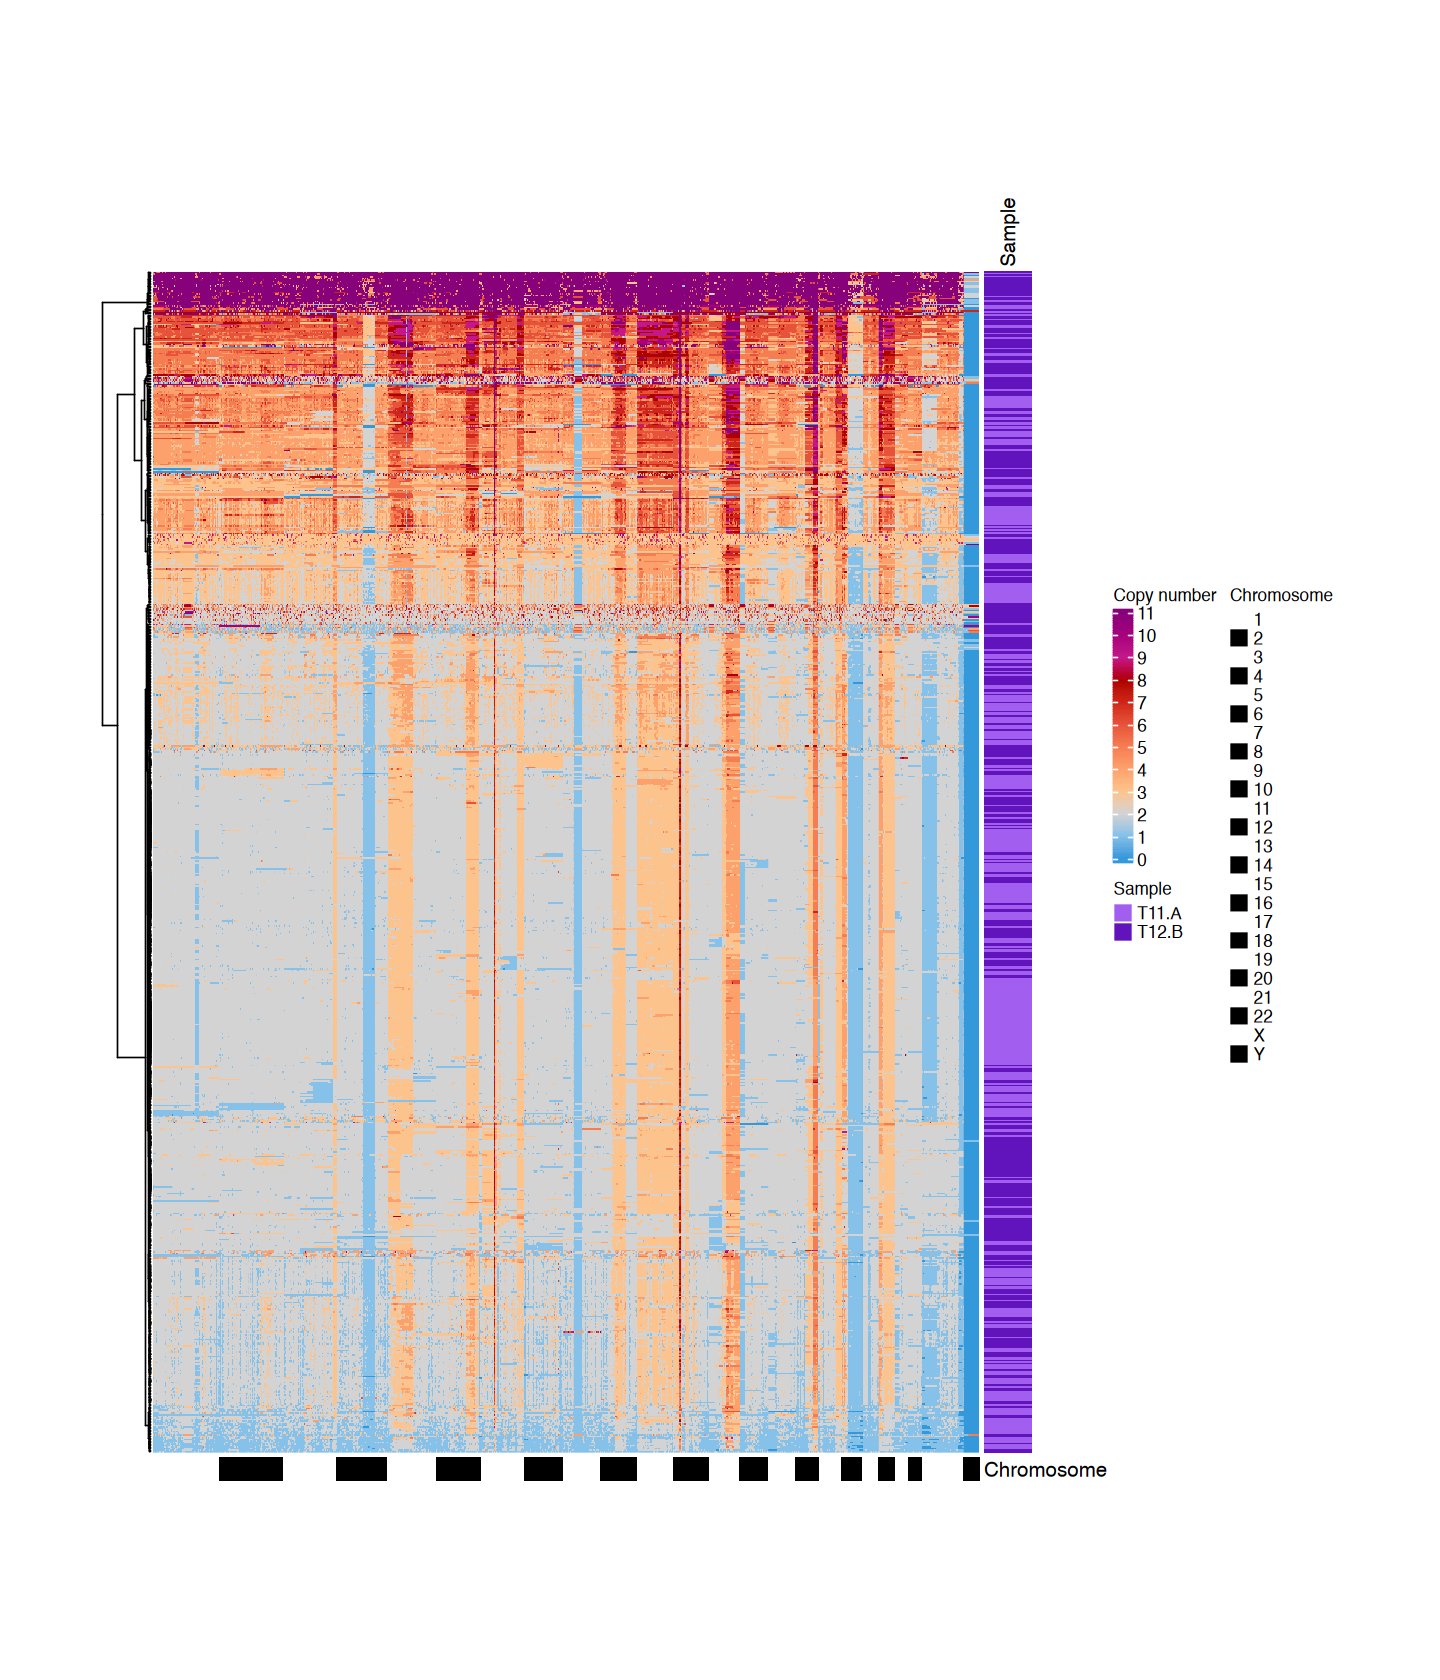

In [38]:
# Format the CNV data 
cnv_data_fil <- rbind(cnv_data_datac_dt1a,cnv_data_datac_dt1b) %>% dplyr::mutate(Location = sprintf("%s:%s-%s",chr,start,end)) %>%
  dplyr::arrange(as.numeric(chr)) %>% 
  dplyr::mutate_at("cell_id",str_replace,"-SW620bc_DT1_P1a|-SW620_DT1_P1b","") %>%
  dplyr::select(cell_id,chr,start,end,state)

colnames(cnv_data_fil) <- c("cell_id","chrom","start","end","state")
sprintf("Total cells = %s",length(unique(cnv_data_fil$cell_id)))

##### --------------------  Plot the CNA heatmap ------------------- #####

# Add genomic position information
cna_data <- cnv_data_fil %>% dplyr::mutate(Location = sprintf("%s:%s-%s",chrom,start,end))

# Format cna data for heatmap plot
cna_df <- cna_data[,c("cell_id","state","Location")] %>% tidyr::pivot_wider(names_from = Location,
                                                                            values_from = `state`)
rownames(cna_df) <- cna_df$cell_id

cna_mat <- as.matrix(cna_df[,-1])
rownames(cna_mat) <- rownames(cna_df)


sample <- unlist(str_split(rownames(cna_df),"_DATAC"))[seq(1,2*nrow(cna_df),2)]
sample[grep("DT1_P1a",sample)] <- "T11.A"
sample[grep("DT1_P1b",sample)] <- "T12.B"


row_annotation_r <- data.frame(sample)
colnames(row_annotation_r) <- c("Sample")
rownames(row_annotation_r) <- rownames(cna_df)


row_annotation_r_h <- ComplexHeatmap::rowAnnotation(df = row_annotation_r,
                                                    col = list( `Sample` =  c( "T11.A"= "#a25fef",
                                                                               "T12.B"= "#6113bc")),
                                                    simple_anno_size = unit(1, "cm"),
                                                    annotation_name_side = "top"
)


# Column annotation to separate chromosomes, listed in order 1,2,3,...,22,X
column_annotation <- data.frame(unlist(strsplit(colnames(cna_mat), split=':', fixed=TRUE))[seq(1,length(colnames(cna_mat))*2,by=2)])
colnames(column_annotation) <- "Chromosome"
rownames(column_annotation) <- colnames(cna_mat)
column_annotation$Chromosome <- factor(column_annotation$Chromosome, levels = c(sprintf("%s",c(1:22)),"X","Y"))

column_annotation_h <- ComplexHeatmap::HeatmapAnnotation(df = column_annotation,
                                                         col = list(Chromosome = c("1"="white", "2"="black", "3"="white", "4"="black",
                                                                                   "5"="white", "6"="black","7"="white", "8"="black",
                                                                                   "9"="white", "10"="black","11"="white", "12"="black",
                                                                                   "13"="white", "14"="black","15"="white", "16"="black",
                                                                                   "17"="white", "18"="black","19"="white", "20"="black",
                                                                                   "21"="white", "22"="black","X"="white","Y"="black") ),
                                                         simple_anno_size = unit(0.5, "cm")
)

# Define heatmap colours

myColor <- c("#3399db","#85c1e9","#d3d3d3","#fdc38d","#fda16c","#f57d52",
             "#e7523a","#cf2518","#ad0000","#c4188a","#a7007c","#87027a")
myBreaks <- seq(0,11,1)

colours <- circlize::colorRamp2(myBreaks,myColor) 


# Plot heatmap
h <- ComplexHeatmap::Heatmap(as.matrix(cna_mat), 
                             col = colours,
                             bottom_annotation = column_annotation_h,
                             right_annotation = row_annotation_r_h,
                             cluster_columns = F,
                             cluster_rows = T,
                             clustering_distance_rows = "manhattan",
                             clustering_method_rows = "ward.D2",
                             show_column_names = FALSE,
                             show_row_names =F,
                             heatmap_legend_param = list(title = "Copy number",
                                                         at = myBreaks),
                             raster_quality = 10,
                             width = unit(17.5,"cm"),
                             height = unit(25,"cm"))
options(repr.plot.width=12, repr.plot.height=14)
ComplexHeatmap::draw(h, heatmap_legend_side="right", annotation_legend_side="right")

Warning message:
“There was 1 warning in `dplyr::arrange()`.
ℹ In argument: `..1 = as.numeric(chr)`.
Caused by warning:
! NAs introduced by coercion”


[1] "Total cells = 320"

Warning message:
“Setting row names on a tibble is deprecated.”
`use_raster` is automatically set to TRUE for a matrix with more than
2000 columns You can control `use_raster` argument by explicitly
setting TRUE/FALSE to it.

Set `ht_opt$message = FALSE` to turn off this message.



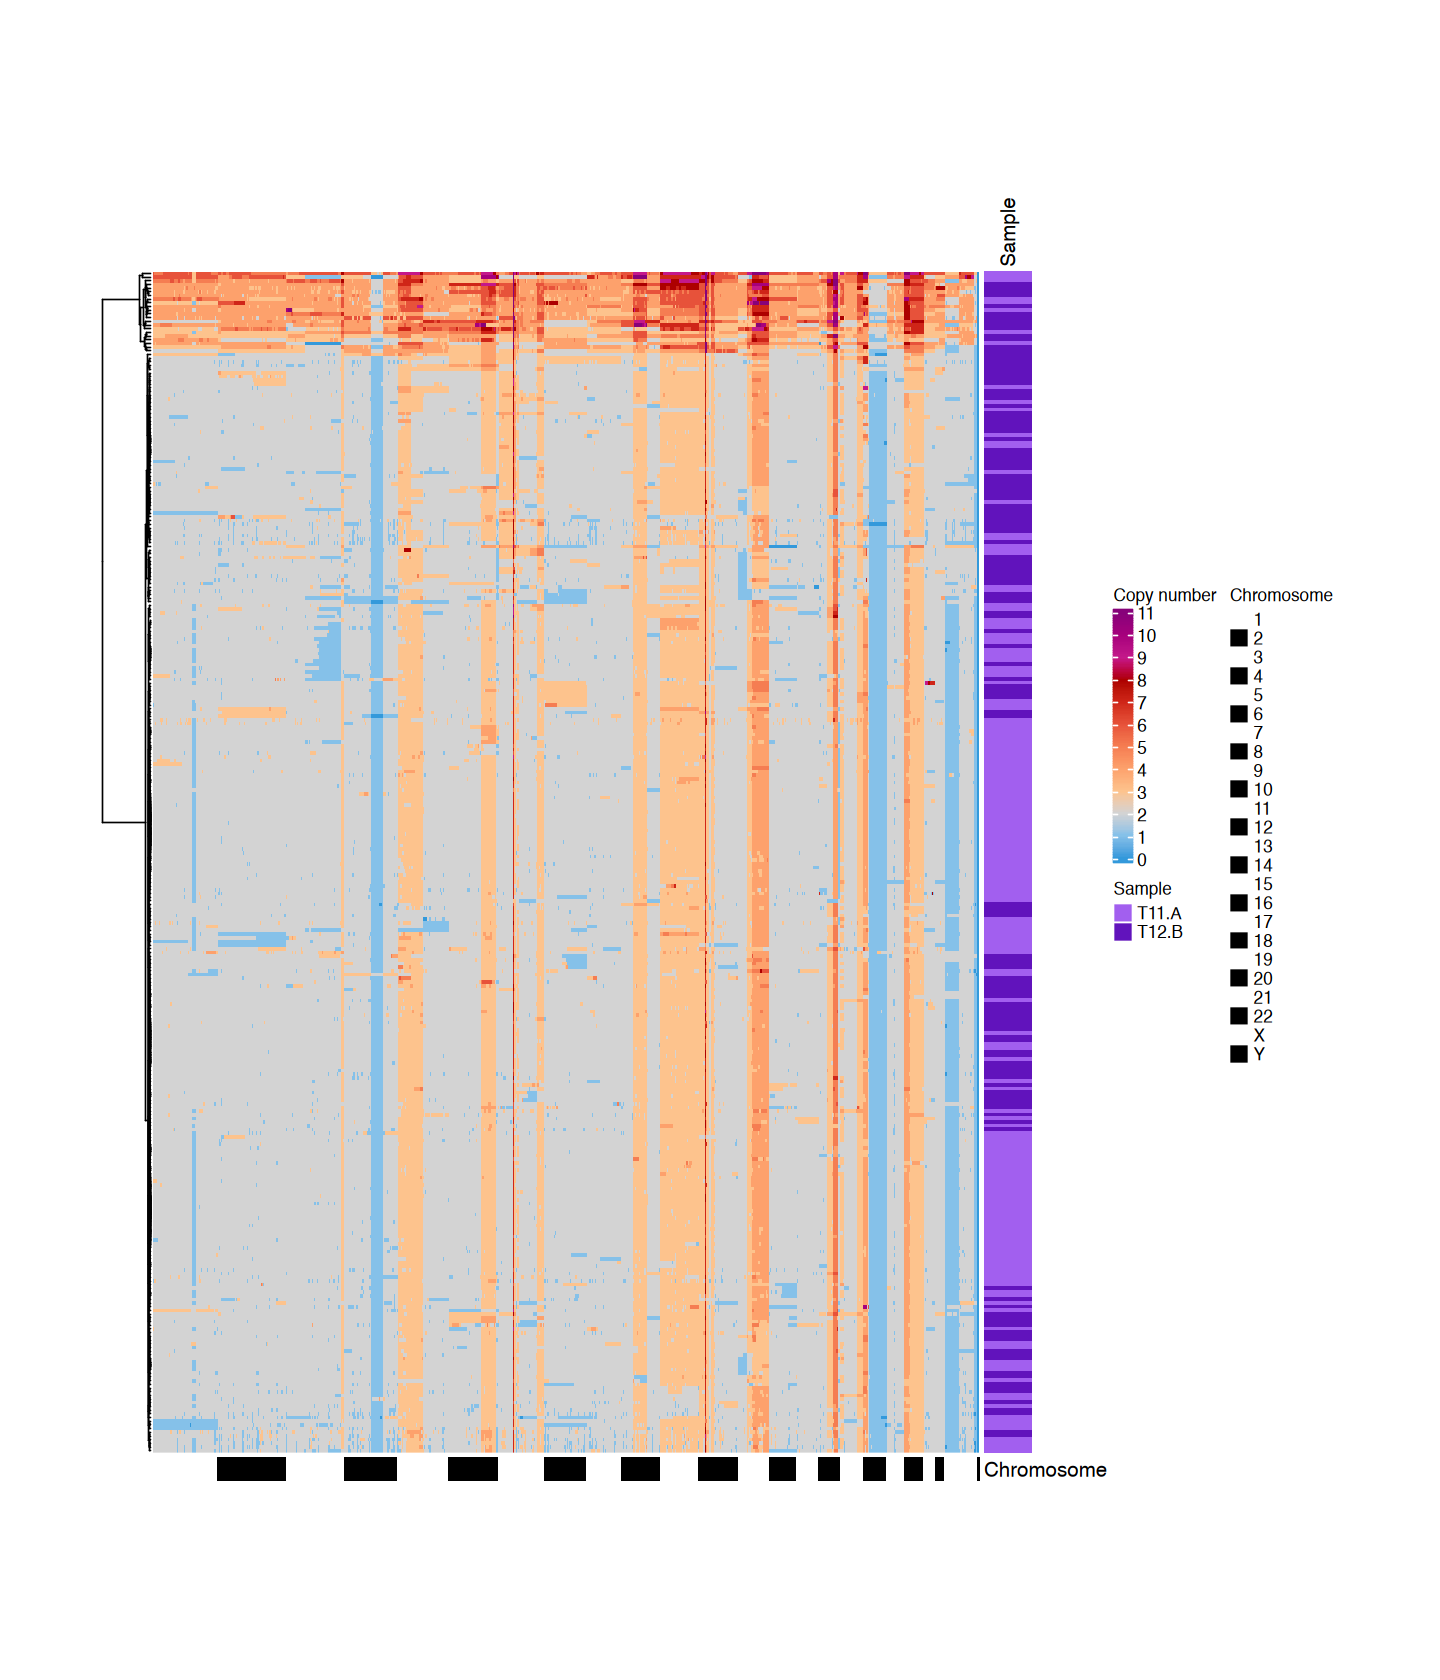

In [39]:
# Format the CNV data 
cnv_data_fil <- rbind(cnv_data_datac_dt1a,cnv_data_datac_dt1b) %>% dplyr::mutate(Location = sprintf("%s:%s-%s",chr,start,end)) %>%
  dplyr::arrange(as.numeric(chr)) %>% 
  dplyr::filter(cell_id %in% metrics[metrics$quality > 0.75 & metrics$is_s_phase == F & metrics$total_mapped_reads_hmmcopy >= 1000000,]$cell_id) %>% 
  dplyr::filter(map > 0.99) %>%
  dplyr::mutate_at("cell_id",str_replace,"-SW620bc_DT1_P1a|-SW620_DT1_P1b","") %>%
  dplyr::select(cell_id,chr,start,end,state)

colnames(cnv_data_fil) <- c("cell_id","chrom","start","end","state")
sprintf("Total cells = %s",length(unique(cnv_data_fil$cell_id)))

##### --------------------  Plot the CNA heatmap ------------------- #####

# Add genomic position information
cna_data <- cnv_data_fil %>% dplyr::mutate(Location = sprintf("%s:%s-%s",chrom,start,end))

# Format cna data for heatmap plot
cna_df <- cna_data[,c("cell_id","state","Location")] %>% tidyr::pivot_wider(names_from = Location,
                                                                            values_from = `state`)
rownames(cna_df) <- cna_df$cell_id

cna_mat <- as.matrix(cna_df[,-1])
rownames(cna_mat) <- rownames(cna_df)


sample <- unlist(str_split(rownames(cna_df),"_DATAC"))[seq(1,2*nrow(cna_df),2)]
sample[grep("DT1_P1a",sample)] <- "T11.A"
sample[grep("DT1_P1b",sample)] <- "T12.B"


row_annotation_r <- data.frame(sample)
colnames(row_annotation_r) <- c("Sample")
rownames(row_annotation_r) <- rownames(cna_df)


row_annotation_r_h <- ComplexHeatmap::rowAnnotation(df = row_annotation_r,
                                                    col = list( `Sample` =  c( "T11.A"= "#a25fef",
                                                                               "T12.B"= "#6113bc")),
                                                    simple_anno_size = unit(1, "cm"),
                                                    annotation_name_side = "top"
)


# Column annotation to separate chromosomes, listed in order 1,2,3,...,22,X
column_annotation <- data.frame(unlist(strsplit(colnames(cna_mat), split=':', fixed=TRUE))[seq(1,length(colnames(cna_mat))*2,by=2)])
colnames(column_annotation) <- "Chromosome"
rownames(column_annotation) <- colnames(cna_mat)
column_annotation$Chromosome <- factor(column_annotation$Chromosome, levels = c(sprintf("%s",c(1:22)),"X","Y"))

column_annotation_h <- ComplexHeatmap::HeatmapAnnotation(df = column_annotation,
                                                         col = list(Chromosome = c("1"="white", "2"="black", "3"="white", "4"="black",
                                                                                   "5"="white", "6"="black","7"="white", "8"="black",
                                                                                   "9"="white", "10"="black","11"="white", "12"="black",
                                                                                   "13"="white", "14"="black","15"="white", "16"="black",
                                                                                   "17"="white", "18"="black","19"="white", "20"="black",
                                                                                   "21"="white", "22"="black","X"="white","Y"="black") ),
                                                         simple_anno_size = unit(0.5, "cm")
)

# Define heatmap colours

myColor <- c("#3399db","#85c1e9","#d3d3d3","#fdc38d","#fda16c","#f57d52",
             "#e7523a","#cf2518","#ad0000","#c4188a","#a7007c","#87027a")
myBreaks <- seq(0,11,1)

colours <- circlize::colorRamp2(myBreaks,myColor) 


# Plot heatmap
h <- ComplexHeatmap::Heatmap(as.matrix(cna_mat), 
                             col = colours,
                             bottom_annotation = column_annotation_h,
                             right_annotation = row_annotation_r_h,
                             cluster_columns = F,
                             cluster_rows = T,
                             clustering_distance_rows = "manhattan",
                             clustering_method_rows = "ward.D2",
                             show_column_names = FALSE,
                             show_row_names =F,
                             heatmap_legend_param = list(title = "Copy number",
                                                         at = myBreaks),
                             raster_quality = 10,
                             width = unit(17.5,"cm"),
                             height = unit(25,"cm"))
options(repr.plot.width=12, repr.plot.height=14)
ComplexHeatmap::draw(h, heatmap_legend_side="right", annotation_legend_side="right")

## Proportions of cells that pass each QC step, across timepoint

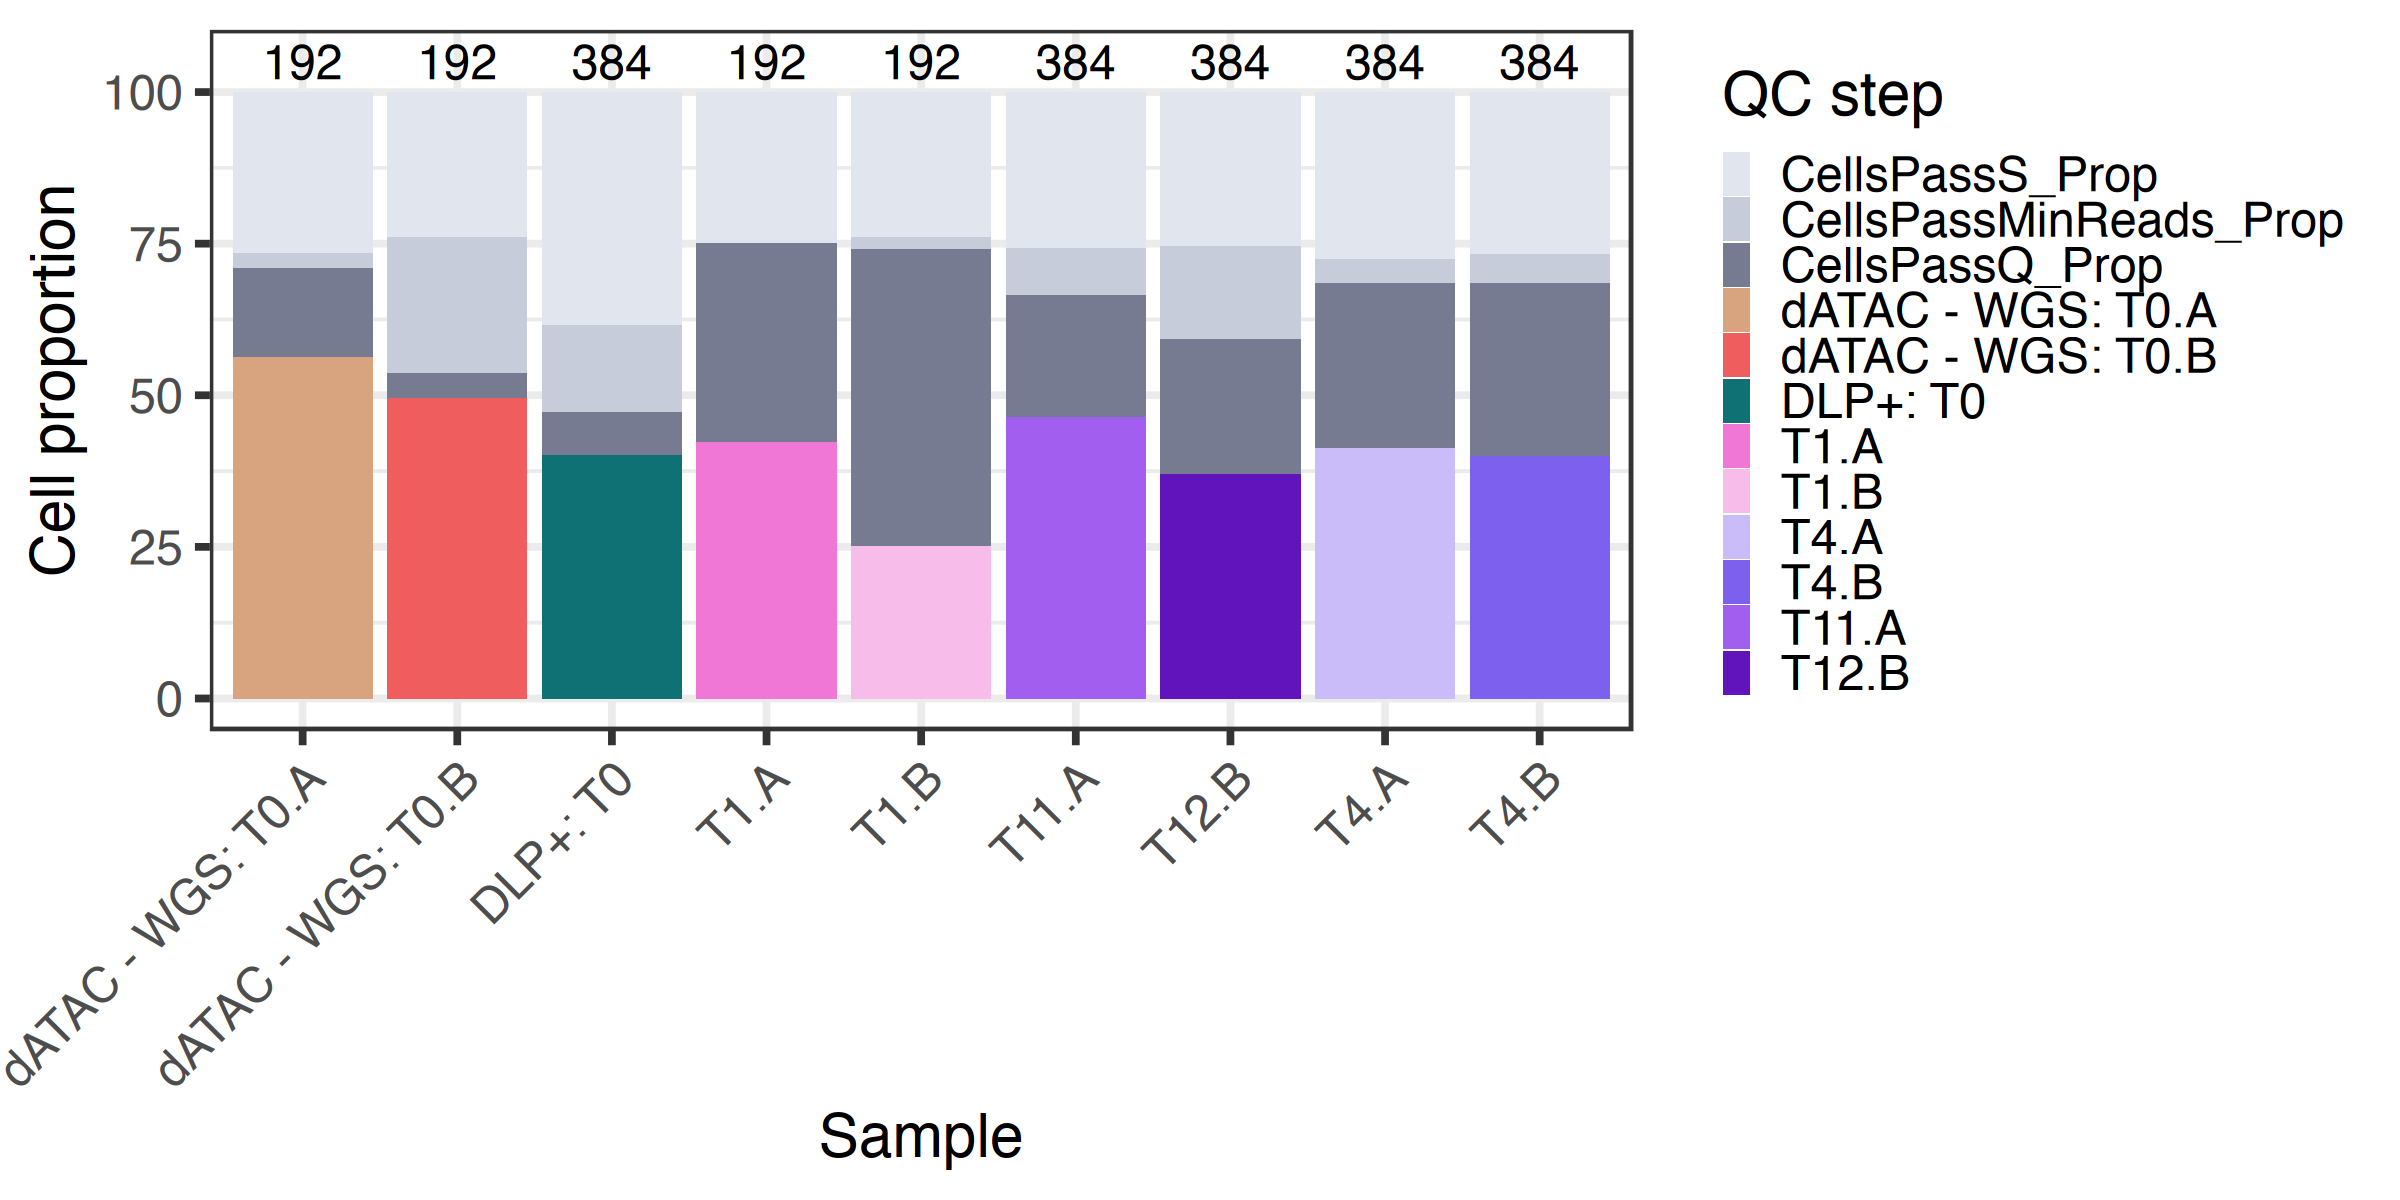

In [61]:
df <- data.frame(read_excel("../Data/CNA_Data/Processed/QC_ProportionCellsPerFilter.xlsx")) 

df_long <- df %>%
  tidyr::pivot_longer(
    cols = ends_with("_Prop"),
    names_to = "QC.metric",
    values_to = "Proportion"
  ) %>% 
 mutate(
    fill_var = if_else(
      QC.metric == "CellsPass_Prop",
      Sample,               # colour by sample
      QC.metric             # otherwise use QC.metric
    )
  )

df_long$QC.metric <- factor(df_long$QC.metric, levels = c("CellsPassS_Prop","CellsPassMinReads_Prop","CellsPassQ_Prop","CellsPass_Prop"))
df_long$fill_var <- factor(df_long$fill_var, levels = c("CellsPassS_Prop","CellsPassMinReads_Prop","CellsPassQ_Prop",
                                                        "dATAC - WGS: T0.A","dATAC - WGS: T0.B","DLP+: T0",
                                                        "T1.A","T1.B", "T4.A","T4.B",
                                                        "T11.A","T12.B"))

df_long$Sample <- factor(df_long$Sample, levels = c("dATAC - WGS: T0.A","dATAC - WGS: T0.B","DLP+: T0",
                                                    "T1.A","T1.B", "T4.A","T4.B",
                                                    "T11.A","T12.B"))


p <- ggplot(data = df_long, aes(x = Sample, y =abs(Proportion),  fill = fill_var))+
  geom_col() +
  scale_fill_manual(name = "QC step",
                    values = c("CellsPassS_Prop" = "#e1e5ee",
                               "CellsPassMinReads_Prop" = "#c7ccdb",
                               "CellsPassQ_Prop" = "#767b91",
                               "dATAC - WGS: T0.A" = "#d8a47f",
                               "dATAC - WGS: T0.B" = "#f05d5e",
                               "DLP+: T0" =  "#0f7173",
                               "T1.A" =  "#f077d6",
                               "T1.B" =  "#f8bceb",
                               "T4.A" = "#c9bcf8",
                               "T4.B" = "#7e60ef",
                               "T11.A"= "#a25fef",
                               "T12.B"= "#6113bc"))+
  geom_text(data = df[,c("Sample","Total.cells")],
            aes(x =`Sample`, y = 105, label = Total.cells),
            inherit.aes = F,# slightly above the bar
            size = 10
  ) +
  xlab("Sample")+
  ylab("Cell proportion")+
  theme_bw(base_size = 36)+
    theme(
        axis.text.x = element_text(angle = 45, hjust = 1)
    )
options(repr.plot.width=20, repr.plot.height=10)
p